In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Polygon

In [ ]:
basepath=""

In [ ]:
def plot_xy_alignments(df):

    df = df.copy().reset_index(drop=True)
    columns = ["Ystart", "Yend", "Xstart", "Xend", "pident"]
    df[columns] = df[columns].apply(pd.to_numeric)

    x_genes_file=f"{basepath}/Annotation/X_genes_1seq_per_gene.tsv"
    genes = pd.read_csv(x_genes_file, sep="\t", header=0).sort_values("Begin")
    blocks = {}
    assignments = []

    for i, row in df.iterrows():
        lo, hi = sorted([row.Xstart, row.Xend])

        # assign only when the entire hit lies in one annotated gene
        candidates = genes[
            (genes["Begin"] <= lo) & (genes["End"] >= hi)
        ]

        if len(candidates) == 1:
            gene = candidates.iloc[0]
            key = gene["Gene ID"]
            blocks[key] = {
                "name": gene["Symbol"],
                "start": gene["Begin"],
                "end": gene["End"],
            }

        elif len(candidates) > 1: # if more than 1 candidate print all names
            key = gene["Gene ID"]
            blocks[key] = {
                "name": candidates["Symbol"].to_list(),
                "start": 0,
                "end": 0,
            }
                
        else: # if no candidate genes
            key = f"unassigned_{i}"
            blocks[key] = {
                "name": f"Unannotated hit {i + 1}",
                "start": lo,
                "end": hi,
            }

        assignments.append(key)

    df["X_gene"] = assignments
    blocks = dict(sorted(blocks.items(), key=lambda item: item[1]["start"]))

    n = len(blocks)
    slot = 0.9 / n

    for i, block in enumerate(blocks.values()):
        block["left"] = 0.05 + i * slot + 0.1 * slot
        block["right"] = block["left"] + 0.8 * slot

    ymin = df[["Ystart", "Yend"]].min().min()
    ymax = df[["Ystart", "Yend"]].max().max()

    def scale(pos, start, end, left, right):
        return left + (right - left) * (pos - start) / max(end - start, 1)

    low, high = df["pident"].min(), df["pident"].max()
    norm = colors.Normalize(low if low < high else low - 1, high)
    cmap = plt.get_cmap("viridis")

    fig, ax = plt.subplots(figsize=(max(12, n * 0.45), 6))

    for row in df.itertuples(index=False):
        block = blocks[row.X_gene]

        ys = scale(row.Ystart, ymin, ymax, 0.1, 0.9)
        ye = scale(row.Yend, ymin, ymax, 0.1, 0.9)

        xs = scale(
            row.Xstart, block["start"], block["end"],
            block["left"], block["right"]
        )
        xe = scale(
            row.Xend, block["start"], block["end"],
            block["left"], block["right"]
        )

        score = float(norm(row.pident))
        colour = cmap(score)

        ax.add_patch(Polygon(
            [(ys, 1), (ye, 1), (xe, 0), (xs, 0)],
            facecolor=colour,
            edgecolor="none",
            alpha=0.15 + 0.75 * score, # the higher identity the less transparent
            zorder=score,
        ))
        
        ax.plot(
            [ys, ye], [1, 1], color=colour, lw=7,
            solid_capstyle="butt", zorder=10 + score # zorder - highest identity is visible on top of overlaps
        )
        ax.plot(
            [xs, xe], [0, 0], color=colour, lw=7,
            solid_capstyle="butt", zorder=10 + score
        )

    ax.plot([0.1, 0.9], [1, 1], color="black", lw=1, zorder=2)
    ax.text(
        0.5, 1.12, f"Y {df['Name'].unique()[0]}: {ymin:,.0f}–{ymax:,.0f}",
        ha="center"
    )

    for block in blocks.values():
        left, right = block["left"], block["right"]
        ax.plot([left, right], [0, 0], color="black", lw=1, zorder=2)
        ax.text(
            (left + right) / 2, -0.04,
            f'{block["name"]}: {block["start"]:,.0f}–{block["end"]:,.0f}',
            rotation=90, ha="center", va="top", fontsize=8
        )

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, label="Sequence identity (%)",
        fraction=0.025, pad=0.03
    )

    ax.set(xlim=(0, 1), ylim=(-0.85, 1.25))
    ax.axis("off")
    fig.tight_layout()

    return fig, ax, df


In [ ]:
def get_identity_plots(ident=90, len=20):
    genes=f"{basepath}/Annotation/genes.csv"
    df_genes = pd.read_csv(genes, sep="\t")

    file=f"{basepath}/Annotation/homologs.rY_XtransSingle.qX.IDT{ident}.W{len}.csv"
    df=pd.read_csv(file, sep="\t", names=["qseqid","sseqid","pident","length","mismatch","gapopen","qstart","qend","sstart","send","evalue","bitscore"])

    df[["Locus_ID", "Ystart", "Yend"]] = df["sseqid"].str.rsplit("_", n=2, expand=True)
    df["Ystart"] = df["Ystart"].astype(int) + df["sstart"].astype(int) - 1
    df["Yend"] = df["Yend"].astype(int) + df["send"].astype(int) - 1
    df["Xstart"] = df["qstart"]
    df["Xend"] = df["qend"]
    
    df=df.merge(df_genes, on="Locus_ID")

    for locus in df["Locus_ID"].unique():
        df_plot=df[df["Locus_ID"] == locus].sort_values("qstart")
        fig, ax, annotated_hits = plot_xy_alignments(df_plot)
        plt.show()

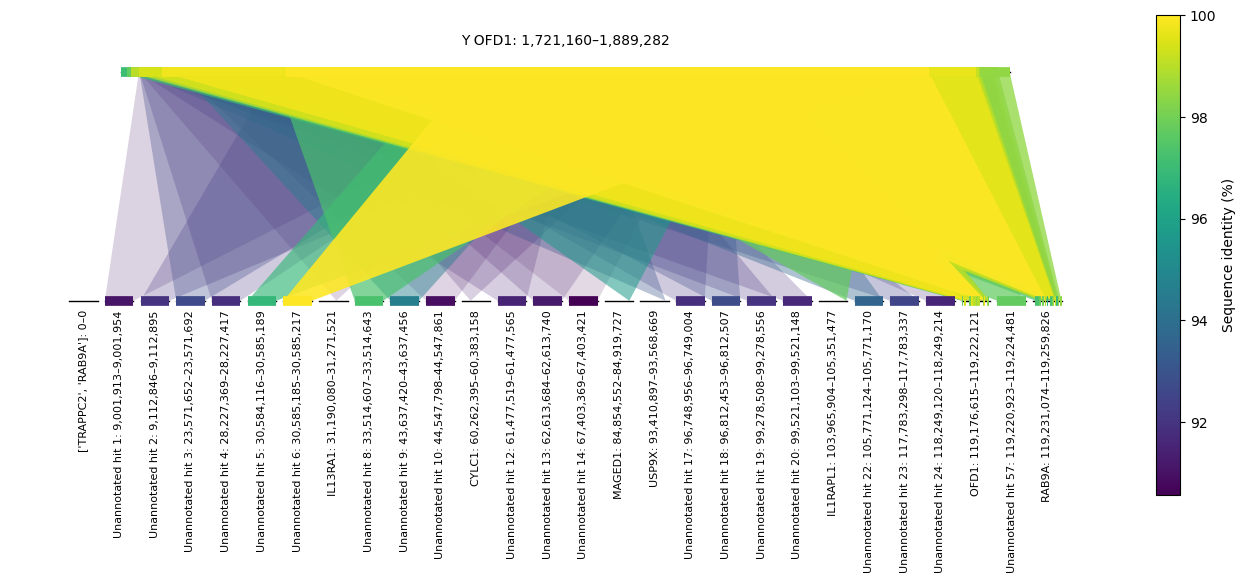

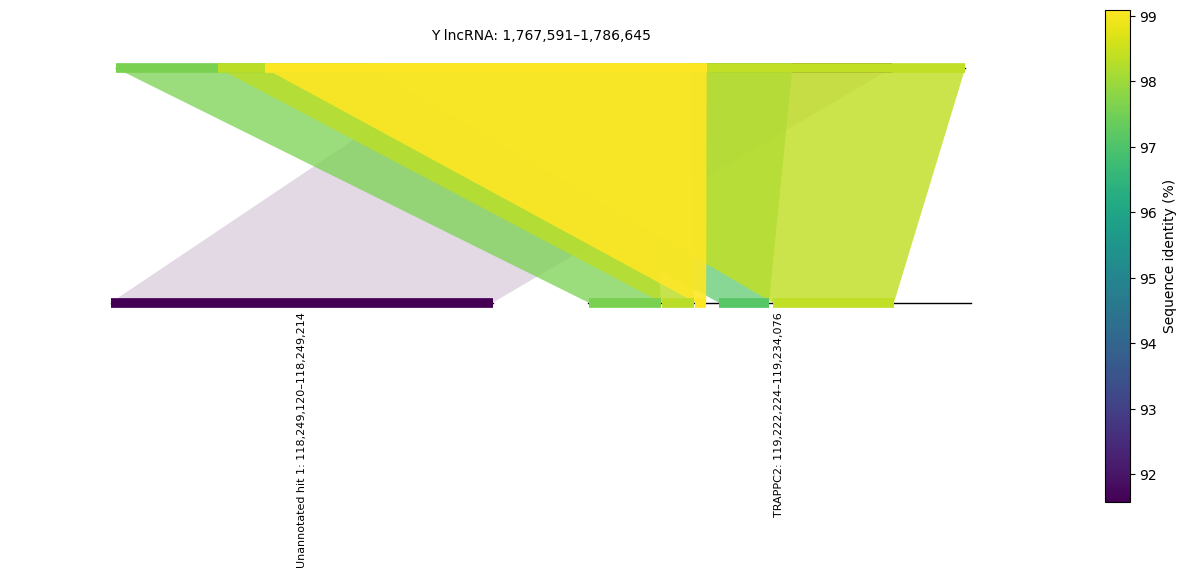

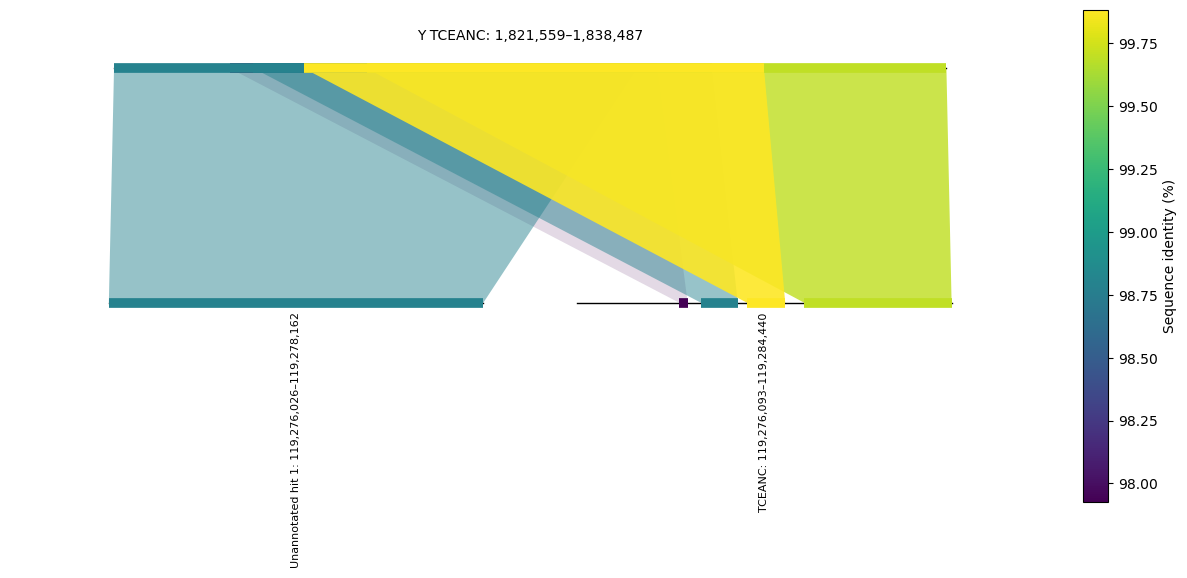

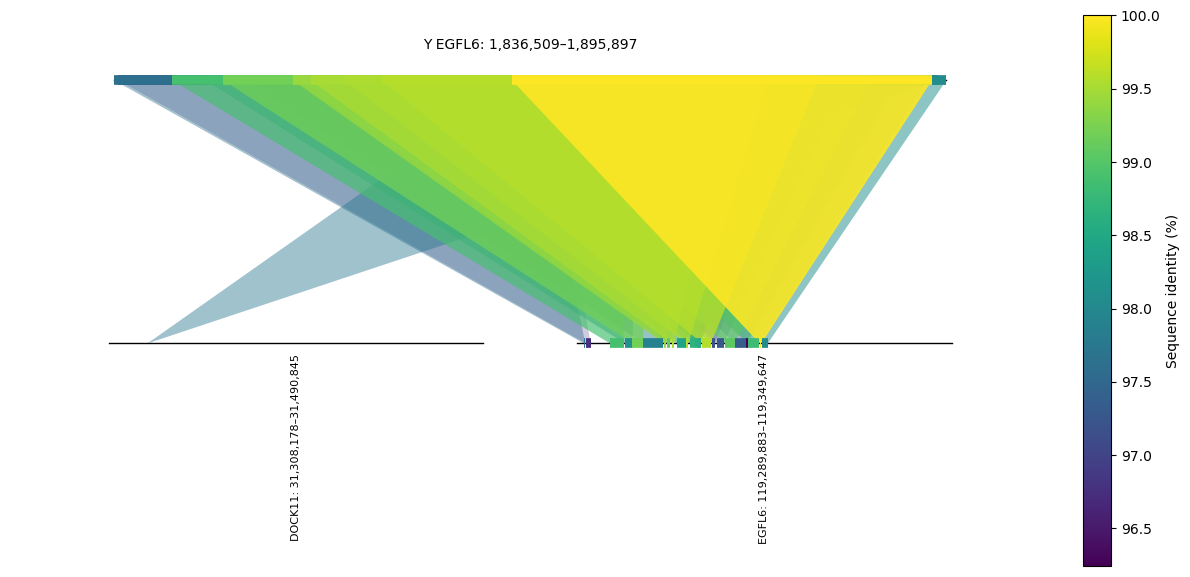

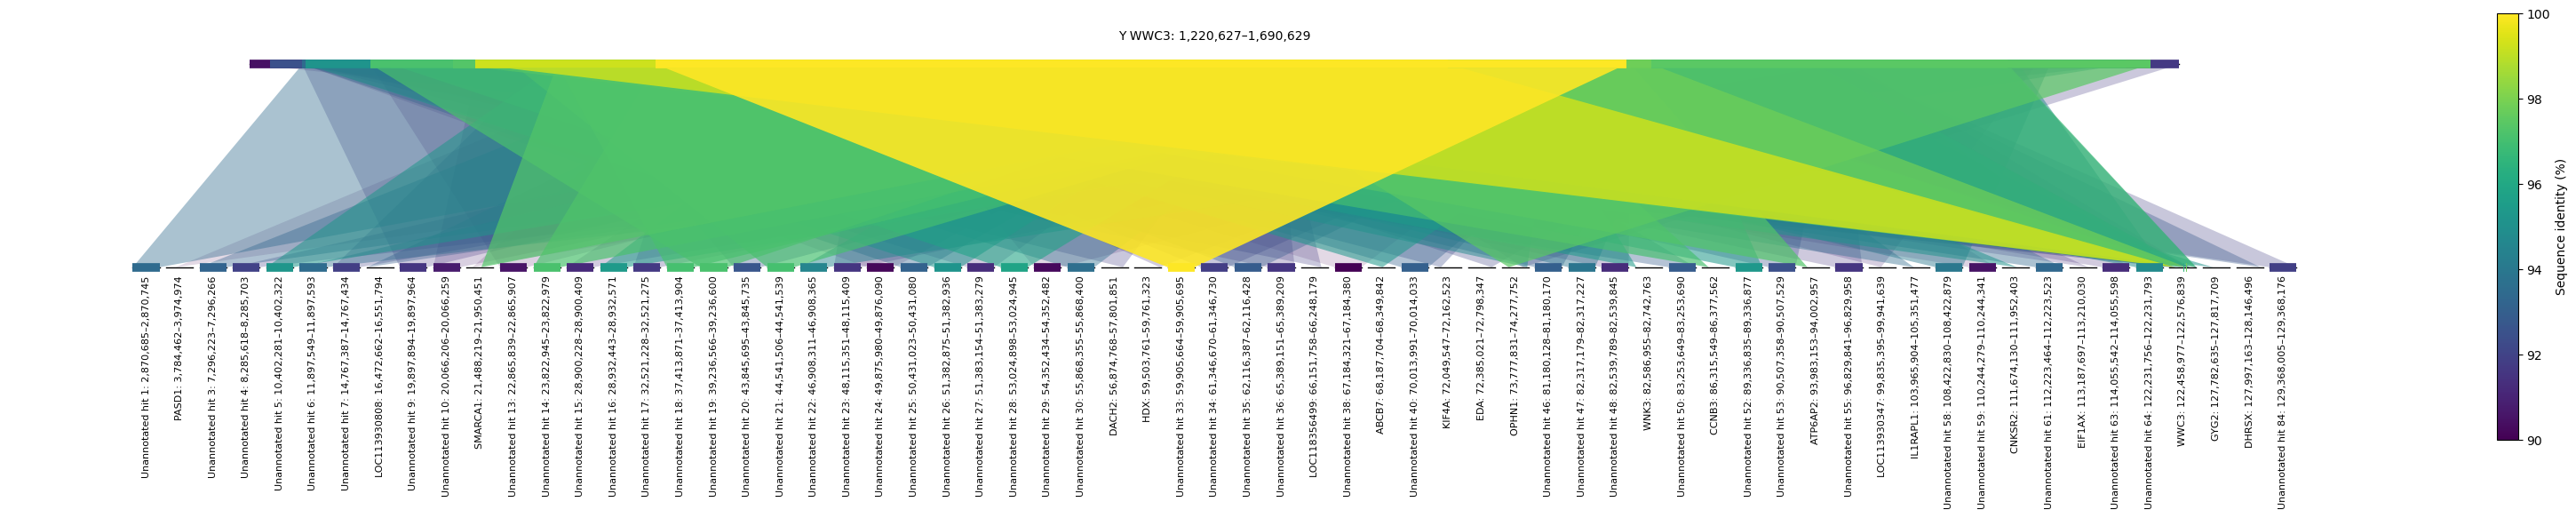

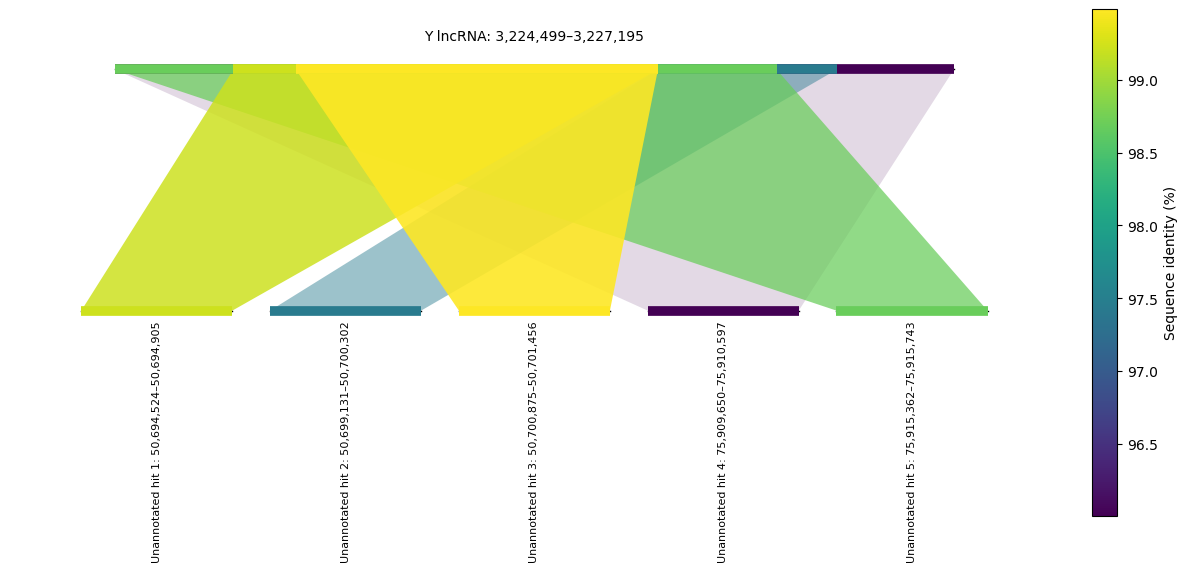

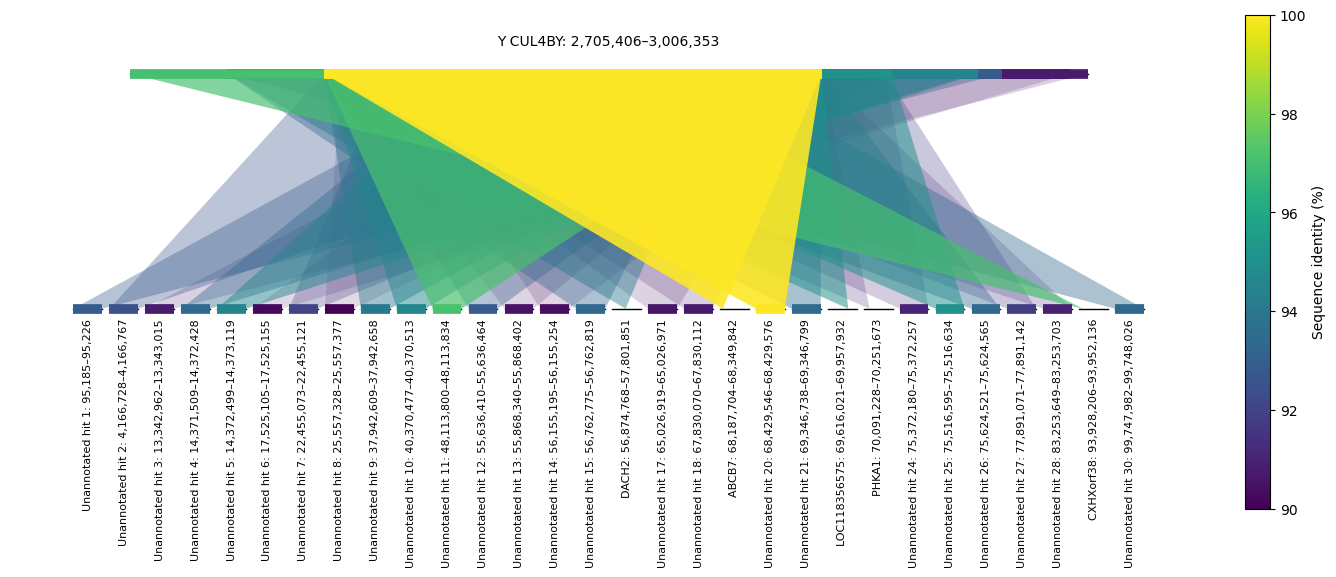

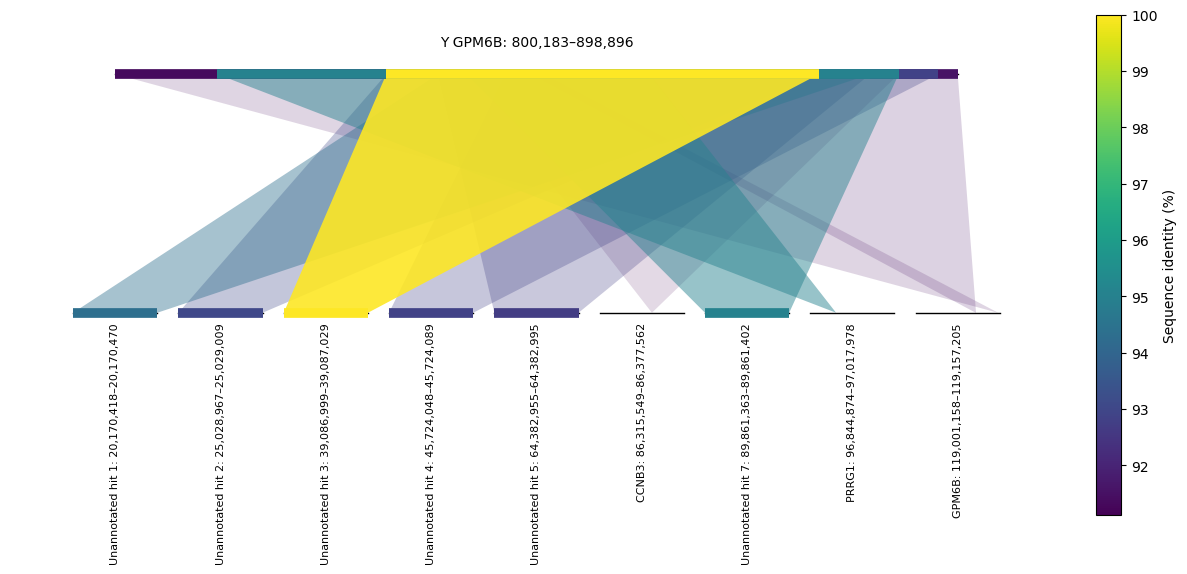

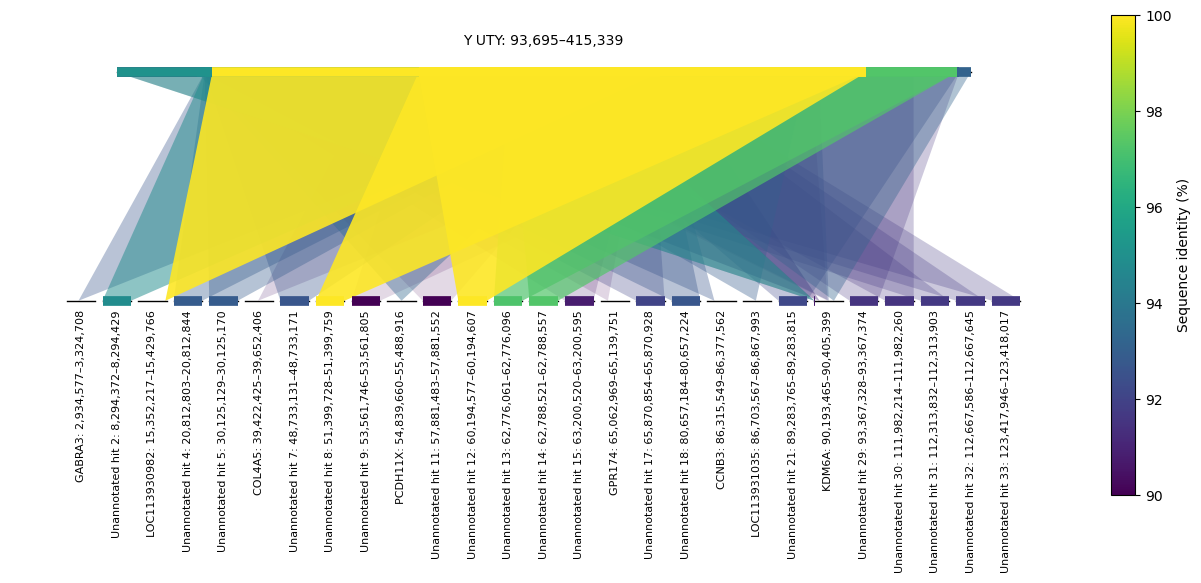

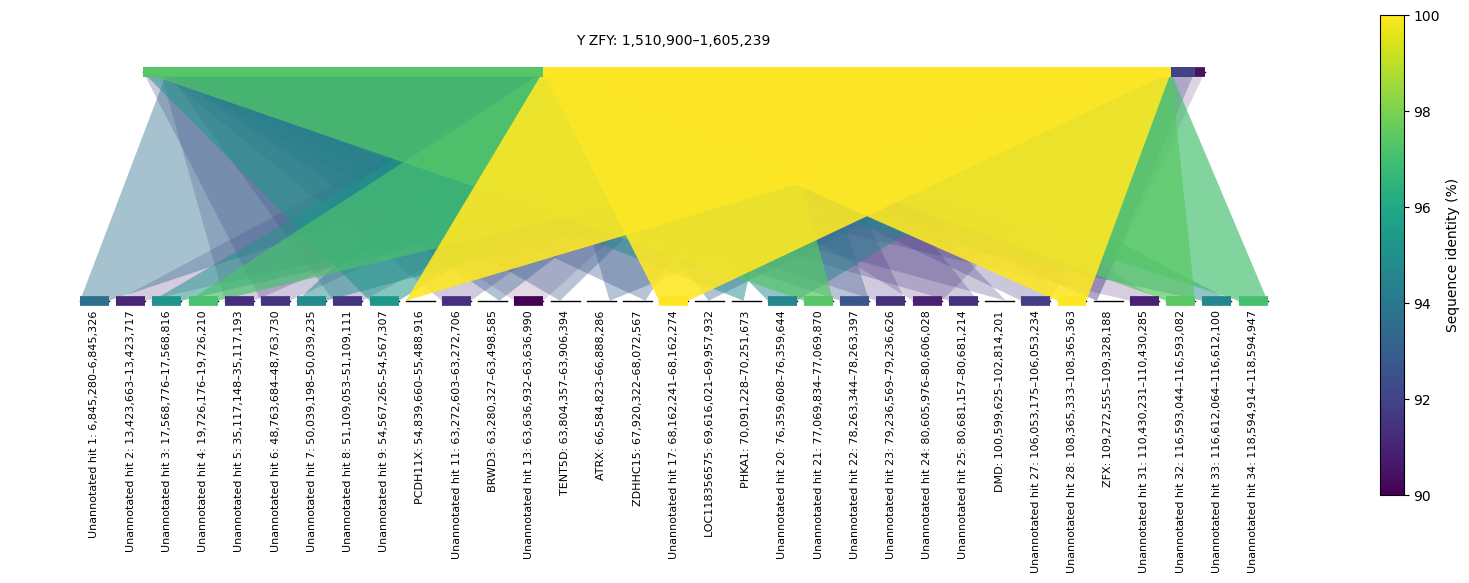

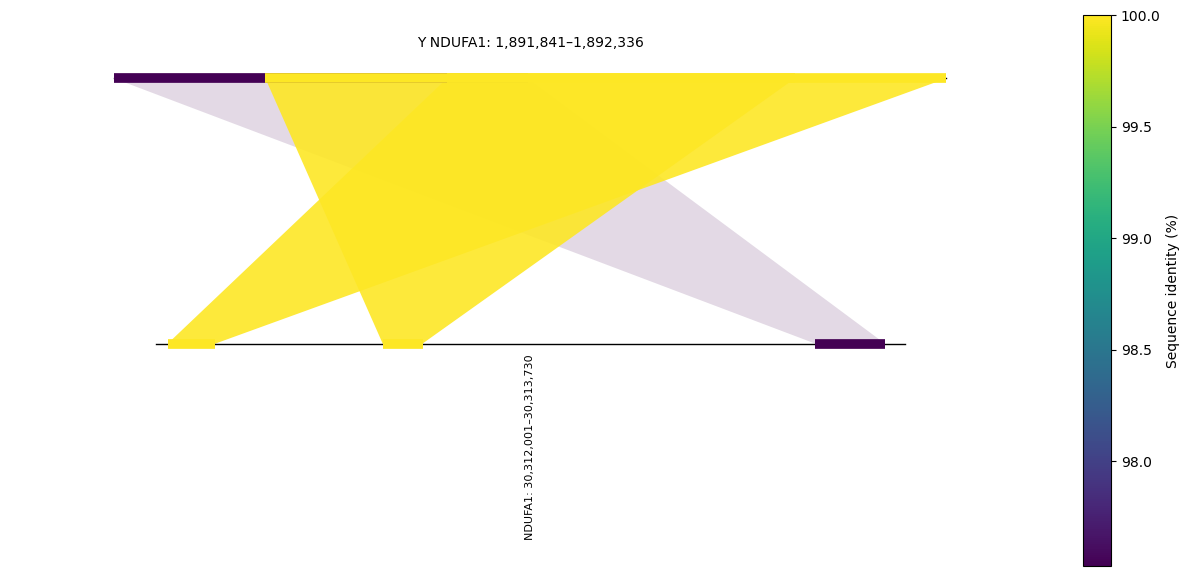

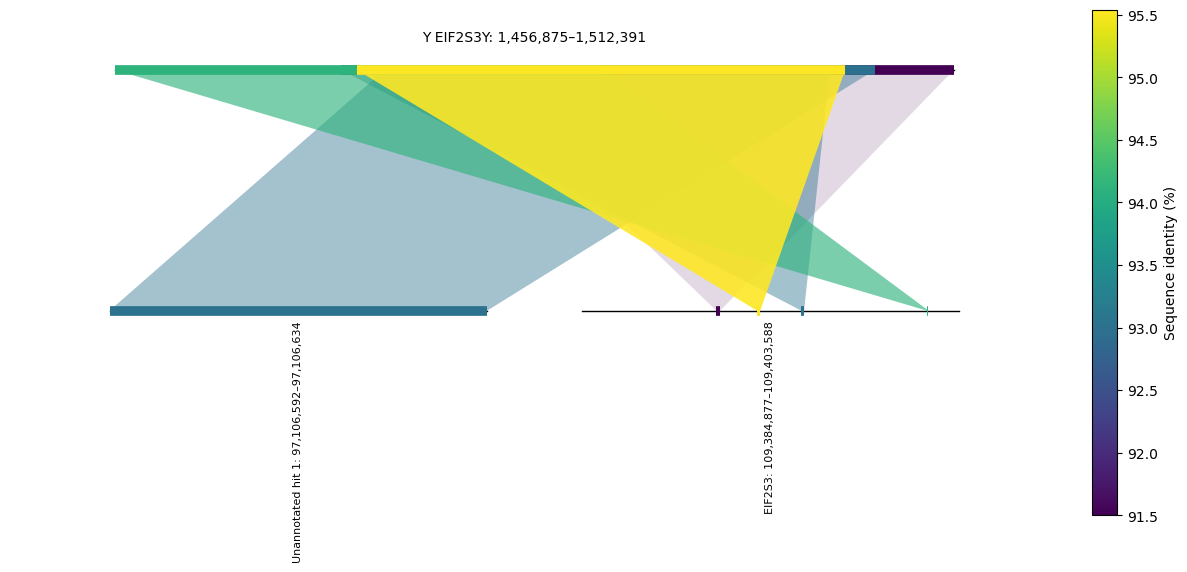

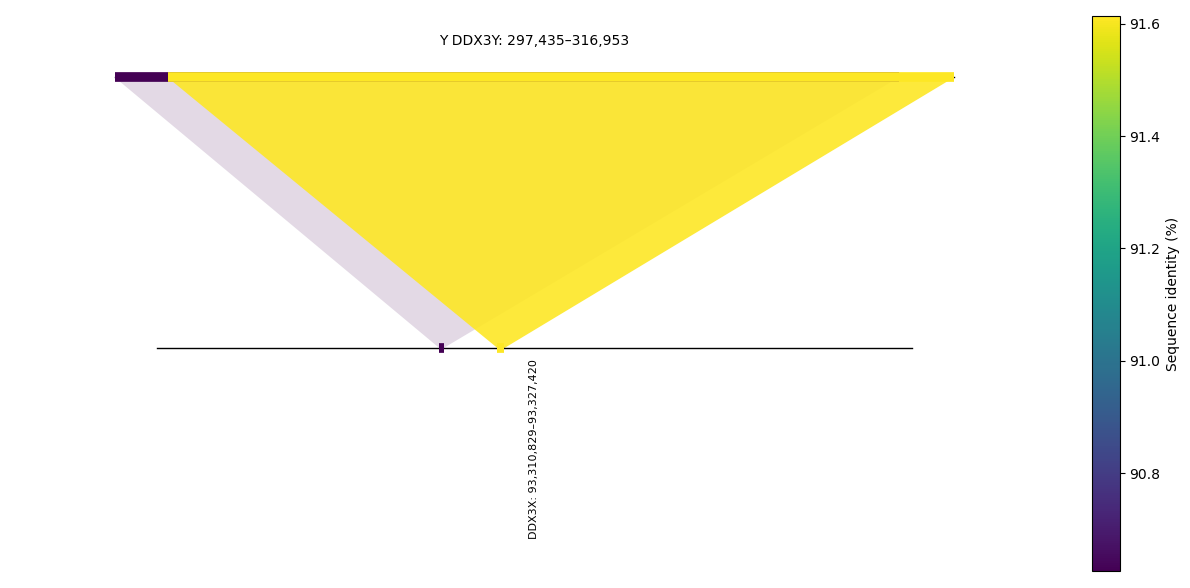

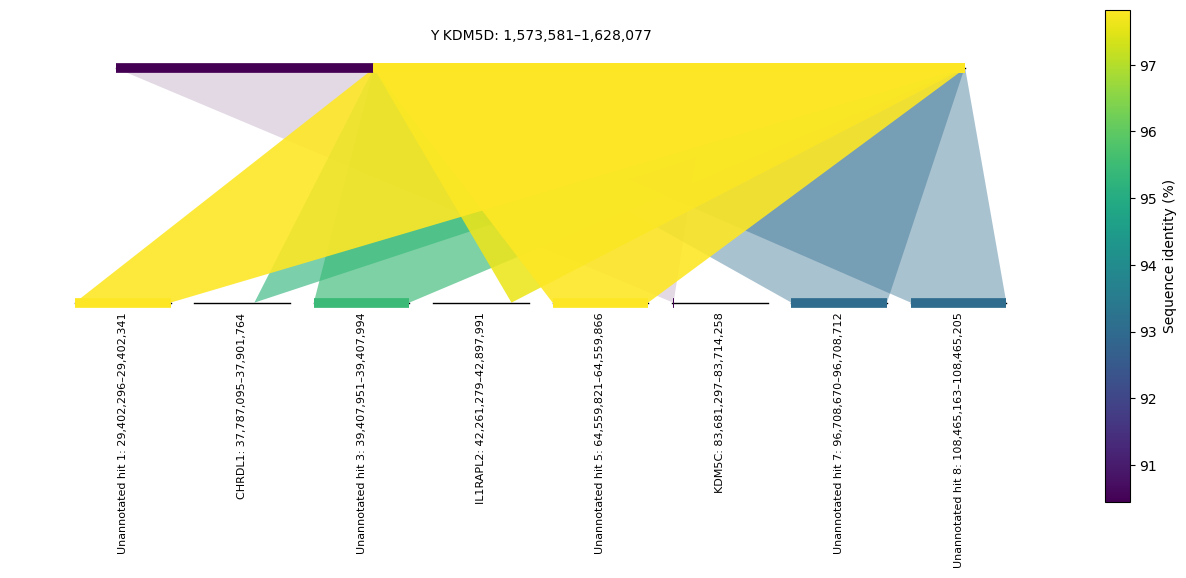

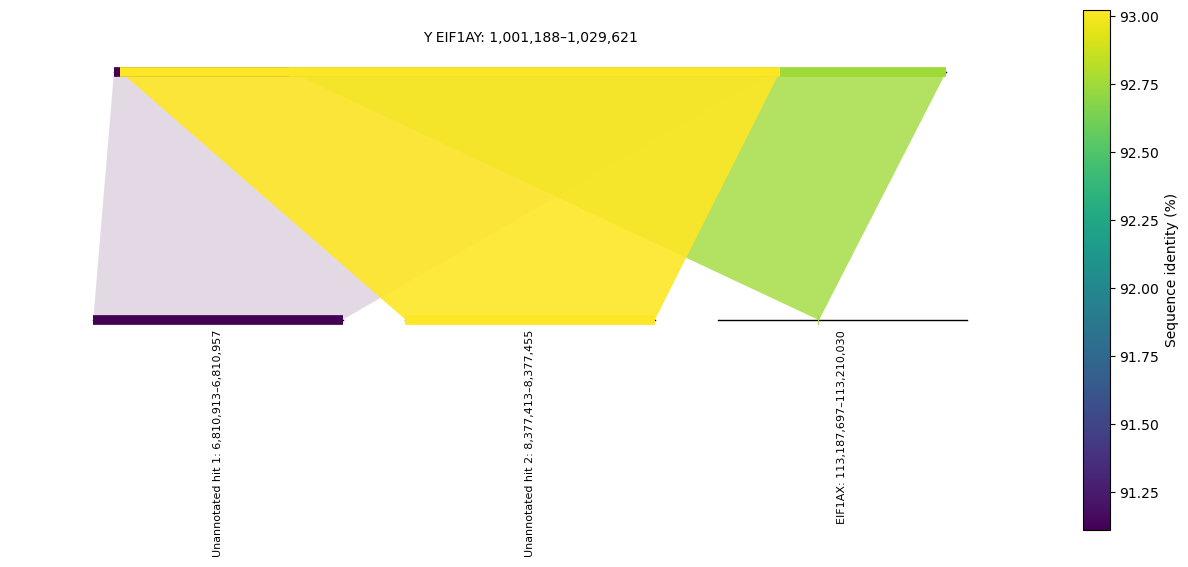

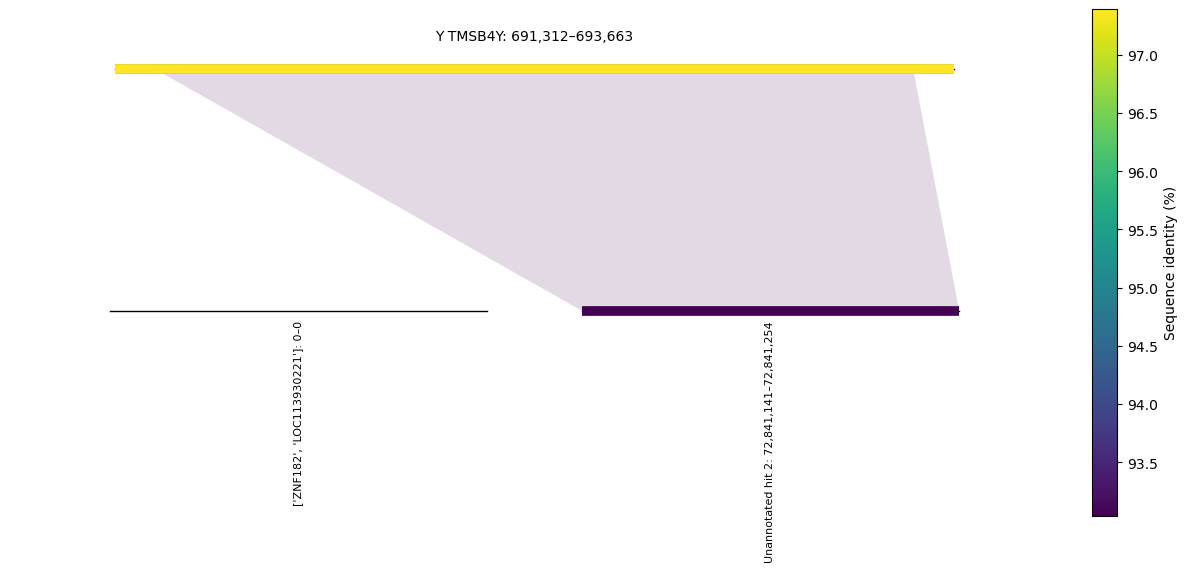

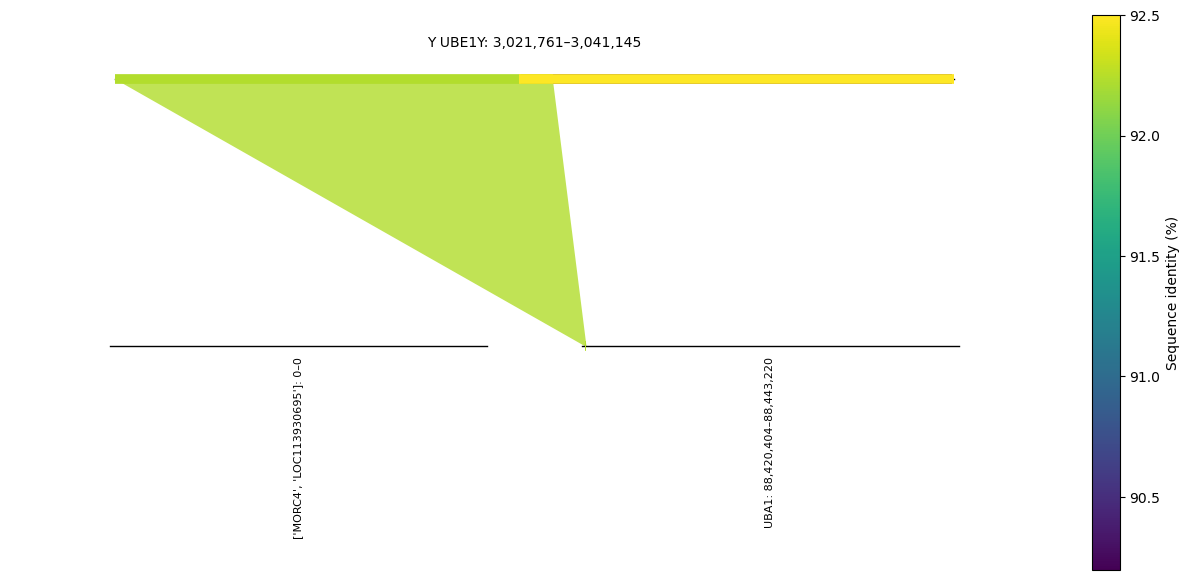

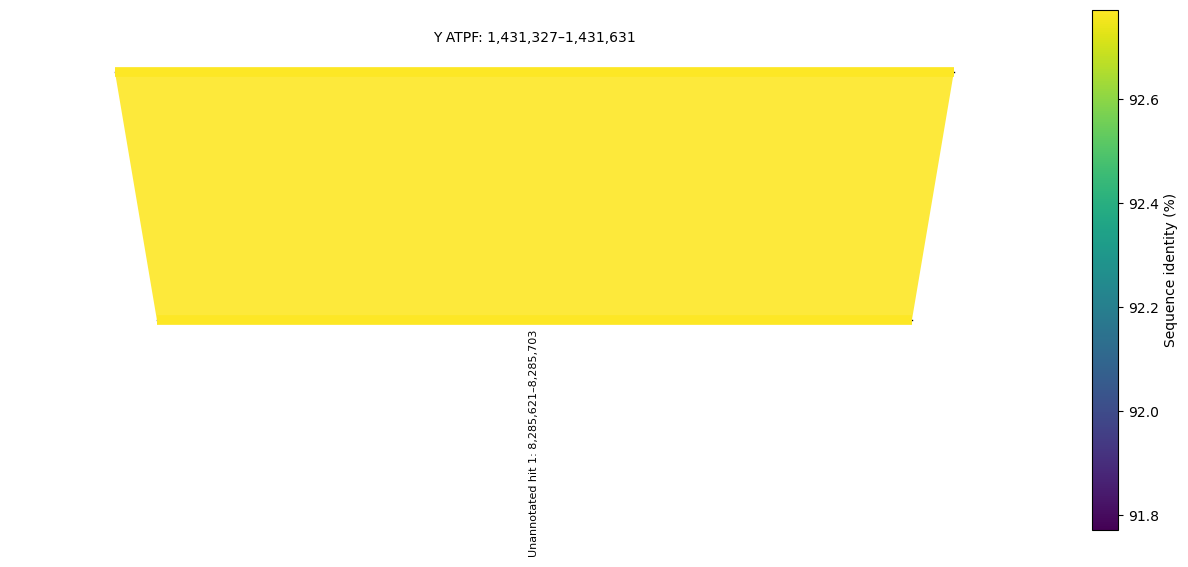

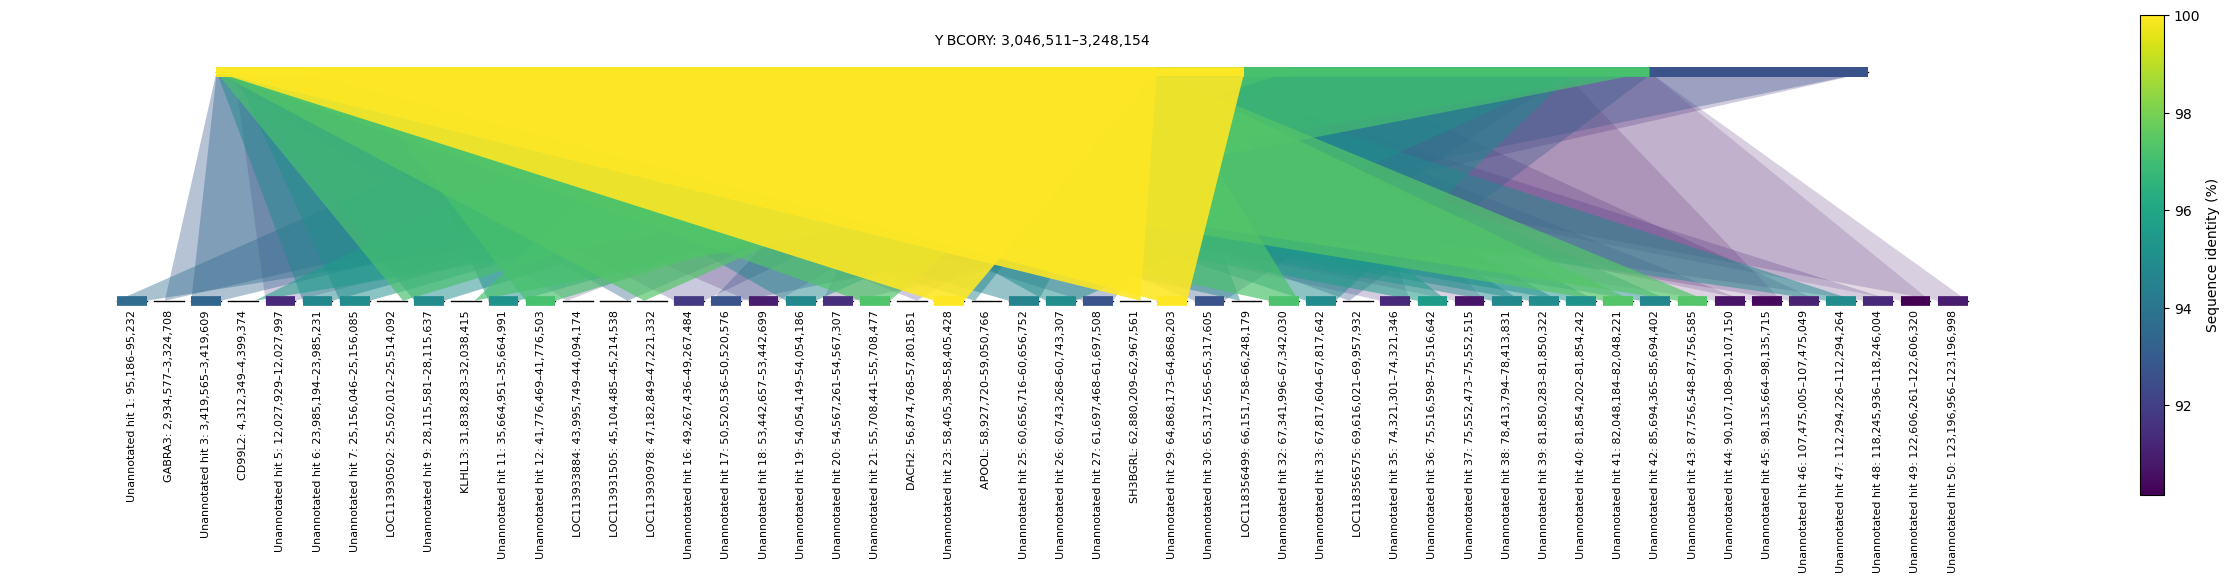

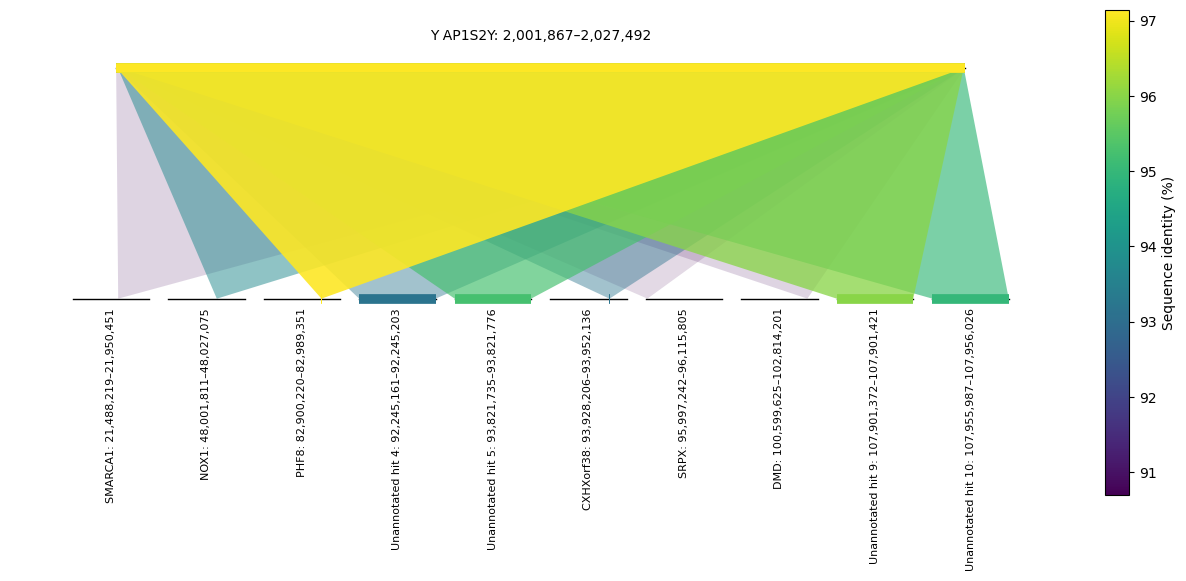

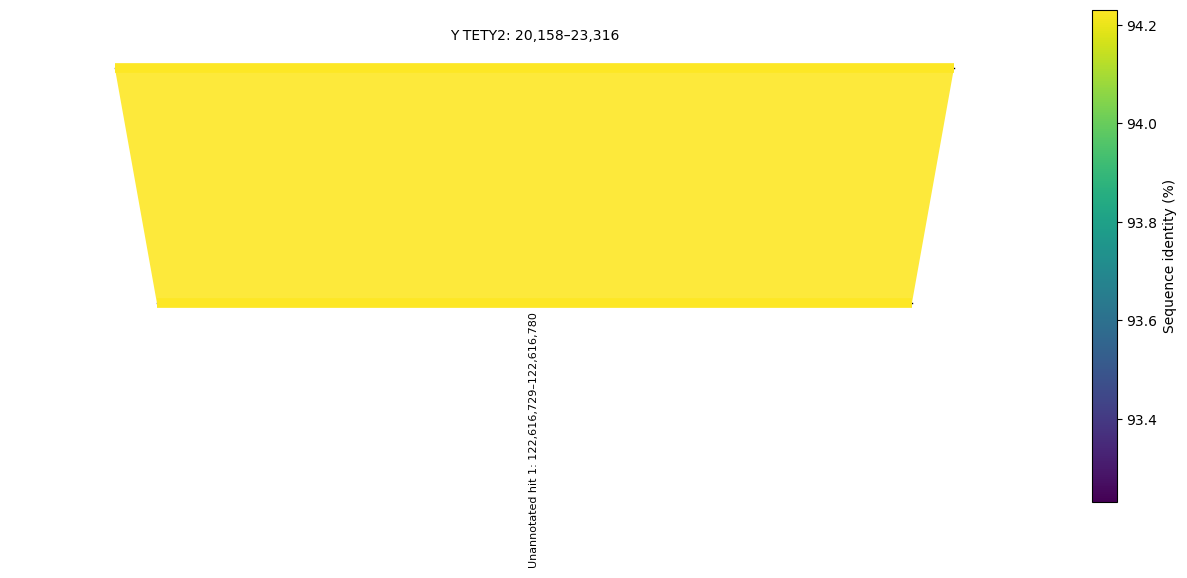

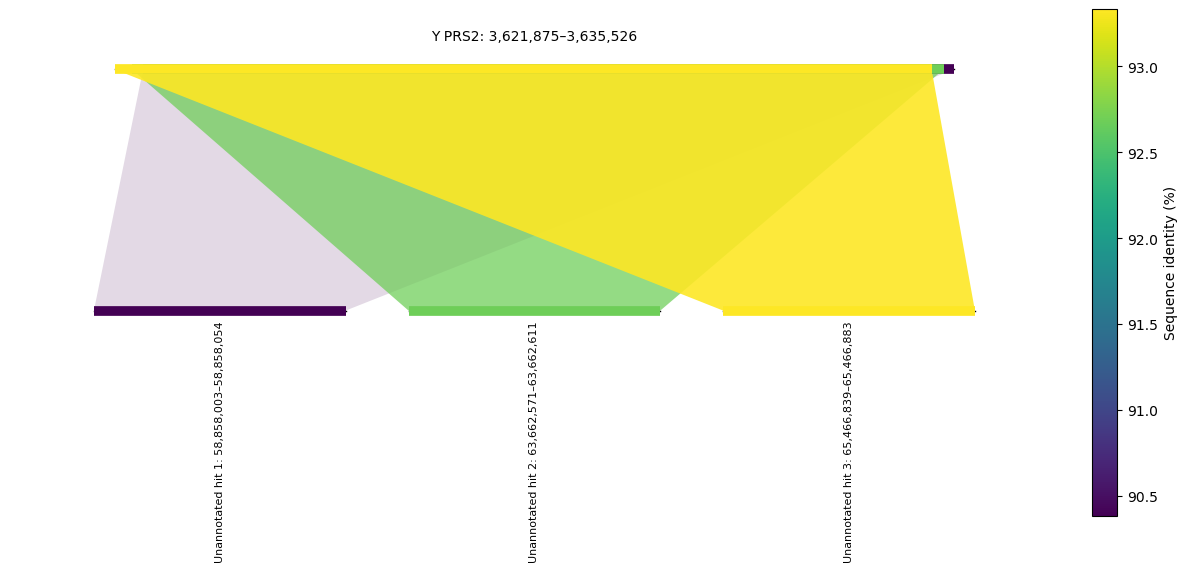

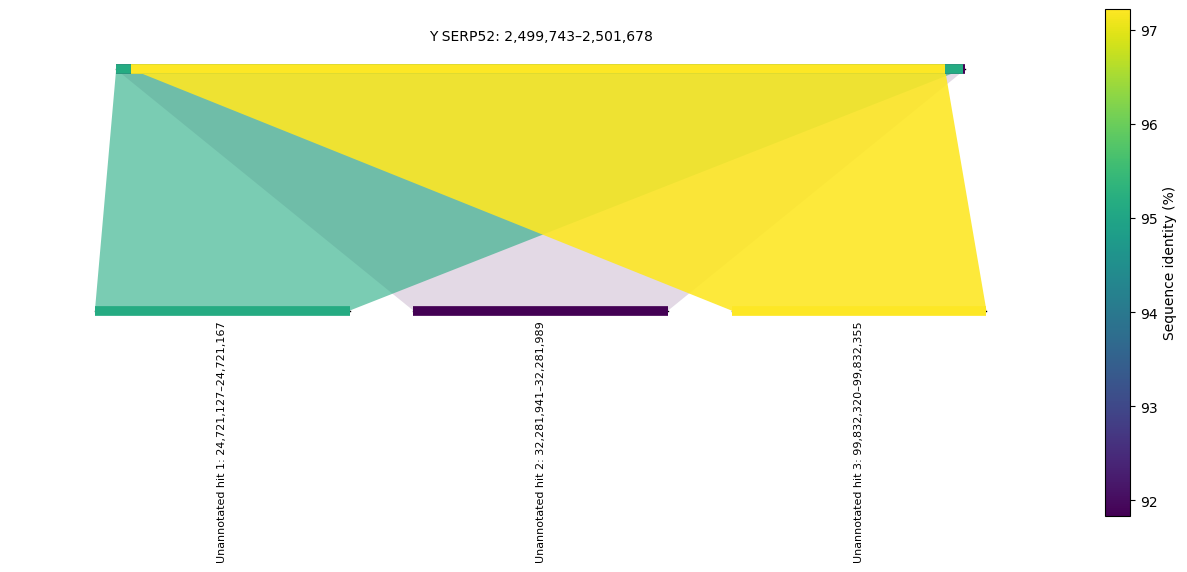

In [4]:
# IDT90.W20
get_identity_plots(ident=90, len=20)

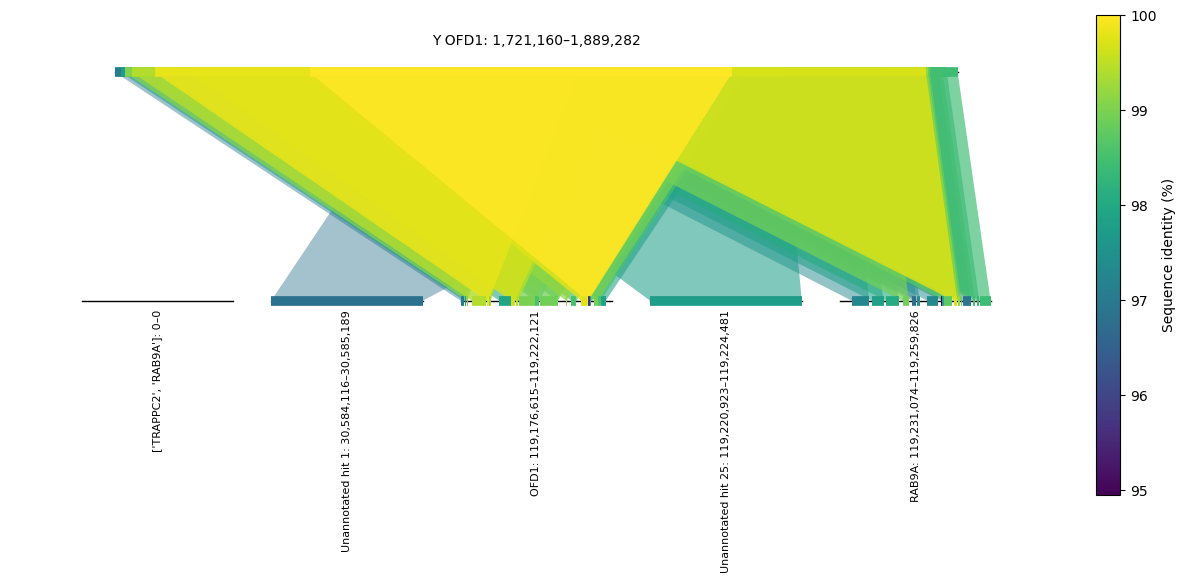

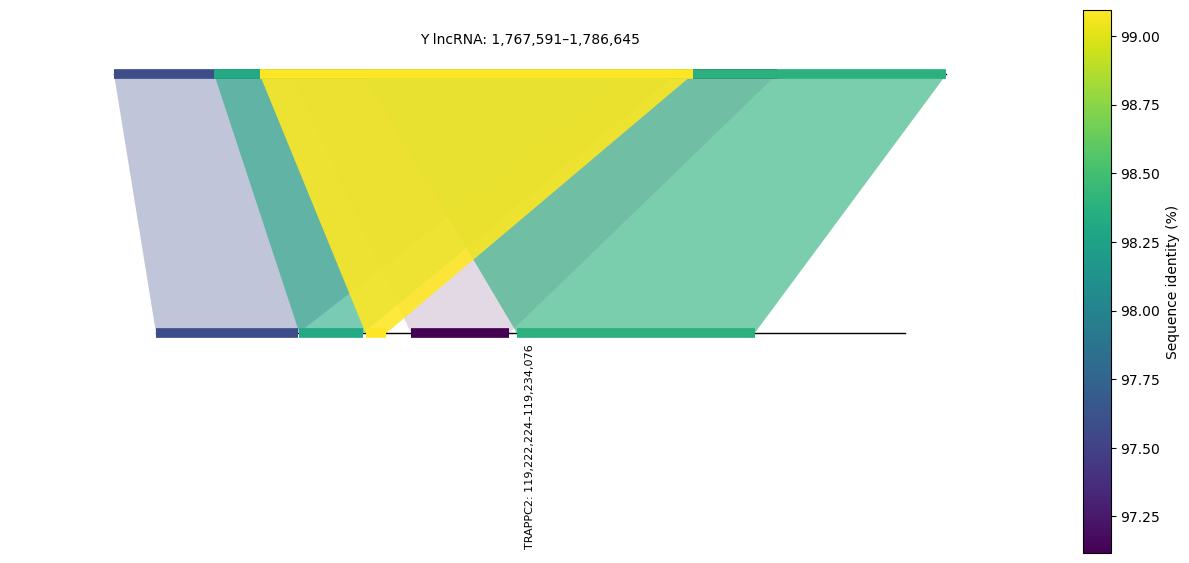

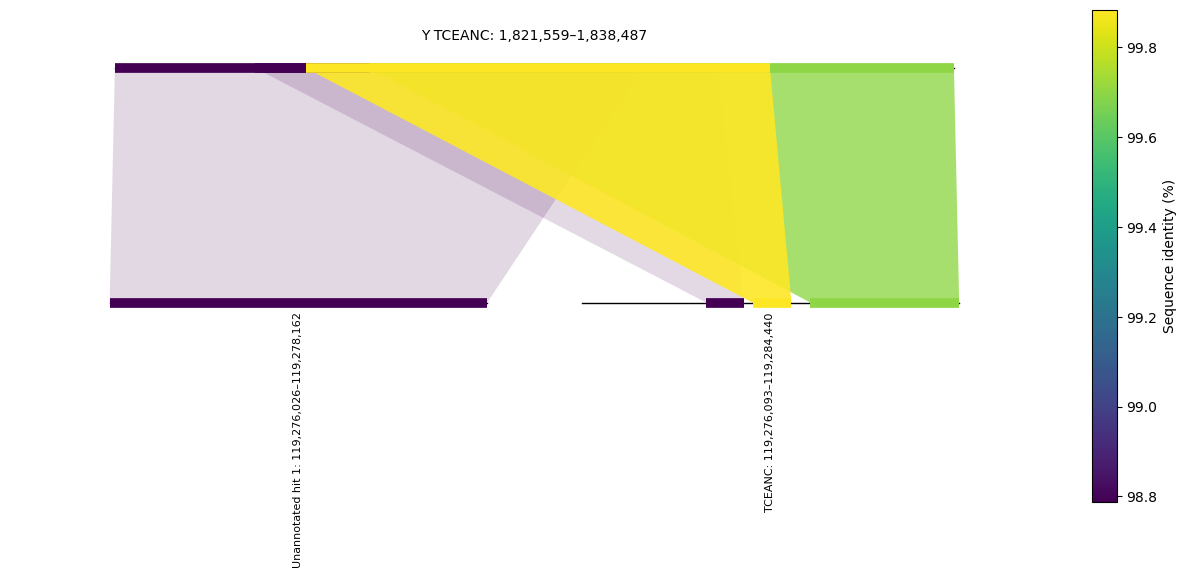

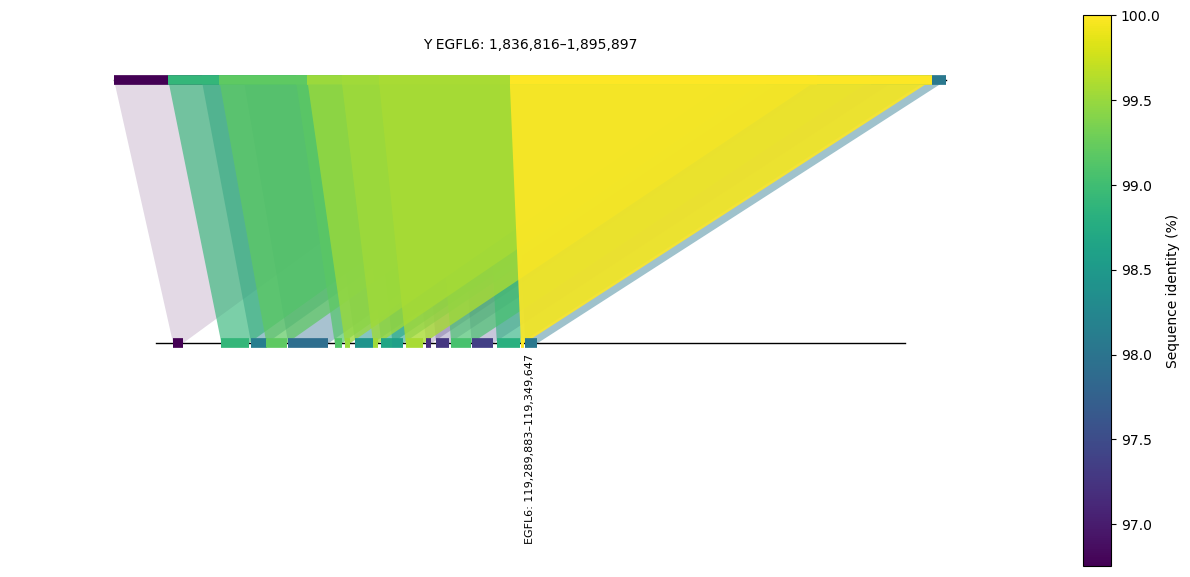

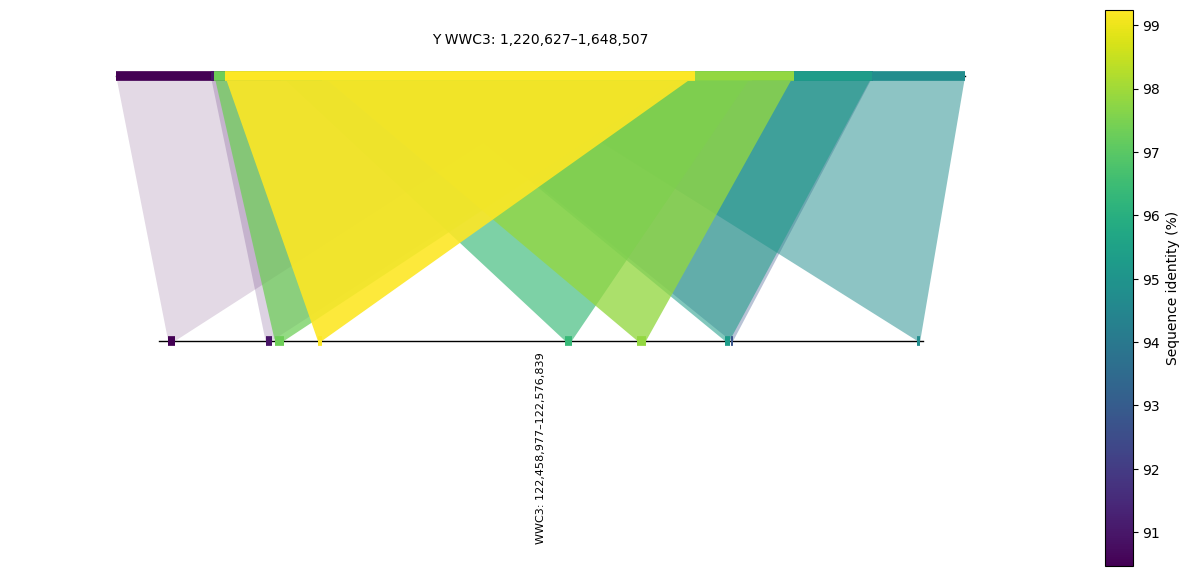

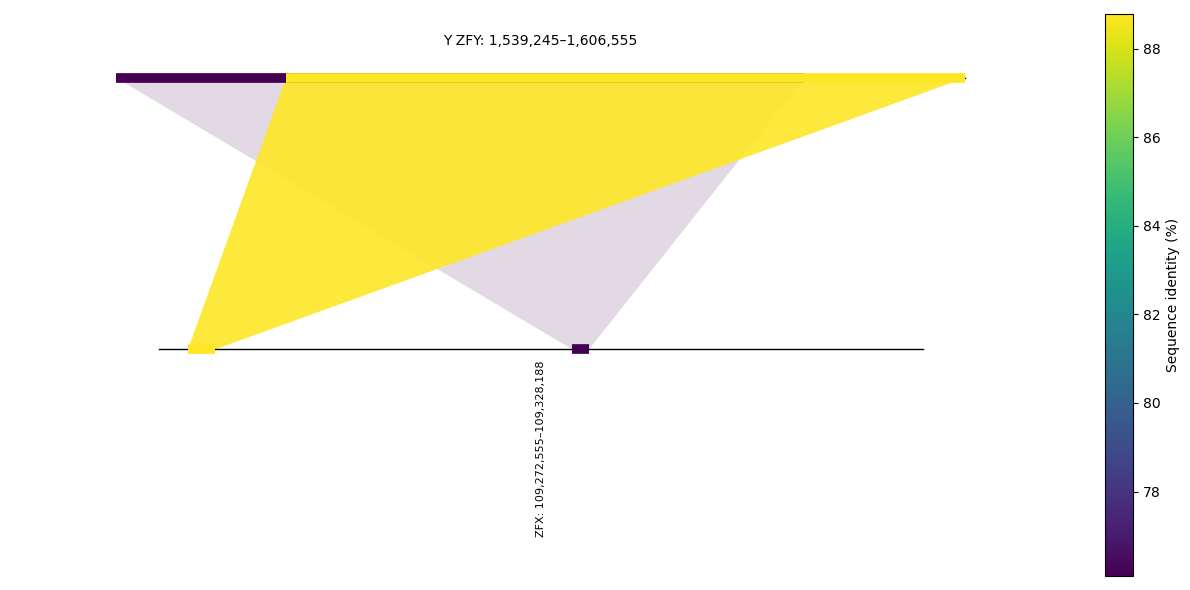

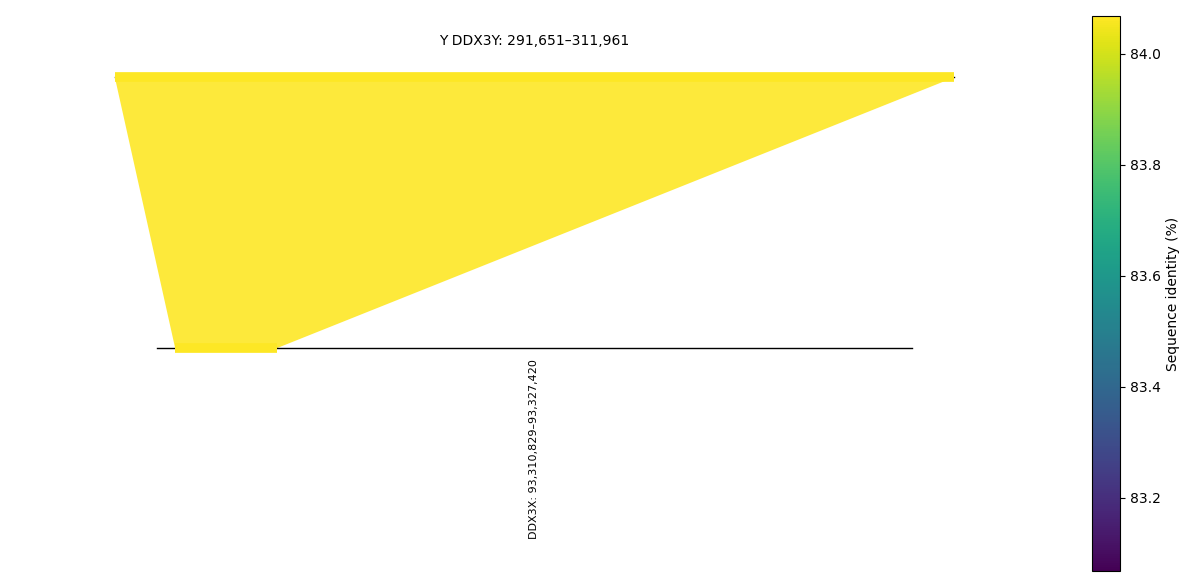

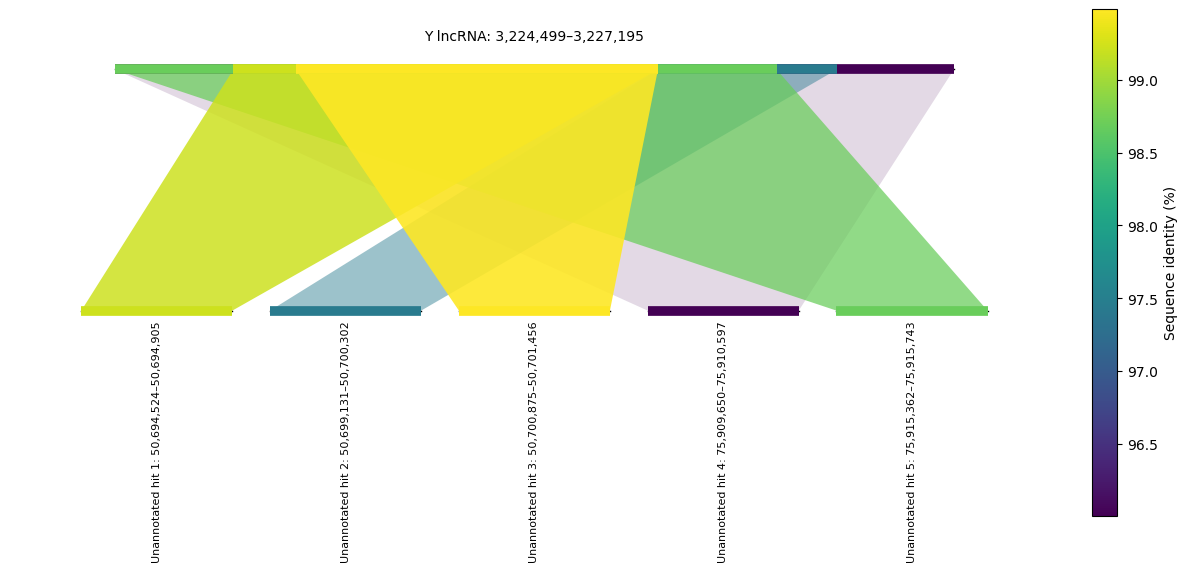

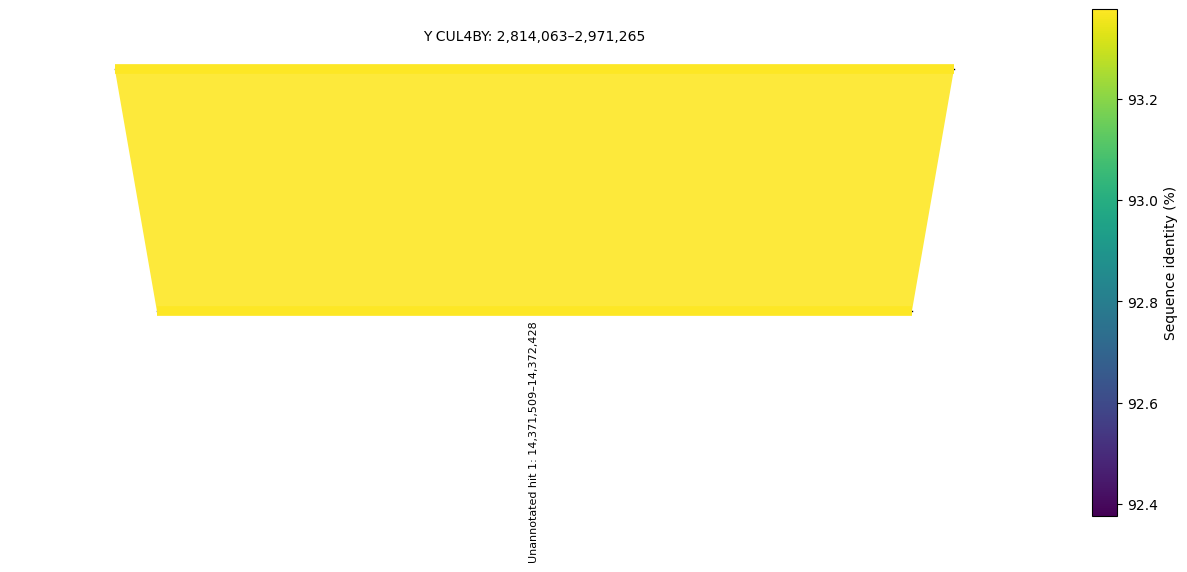

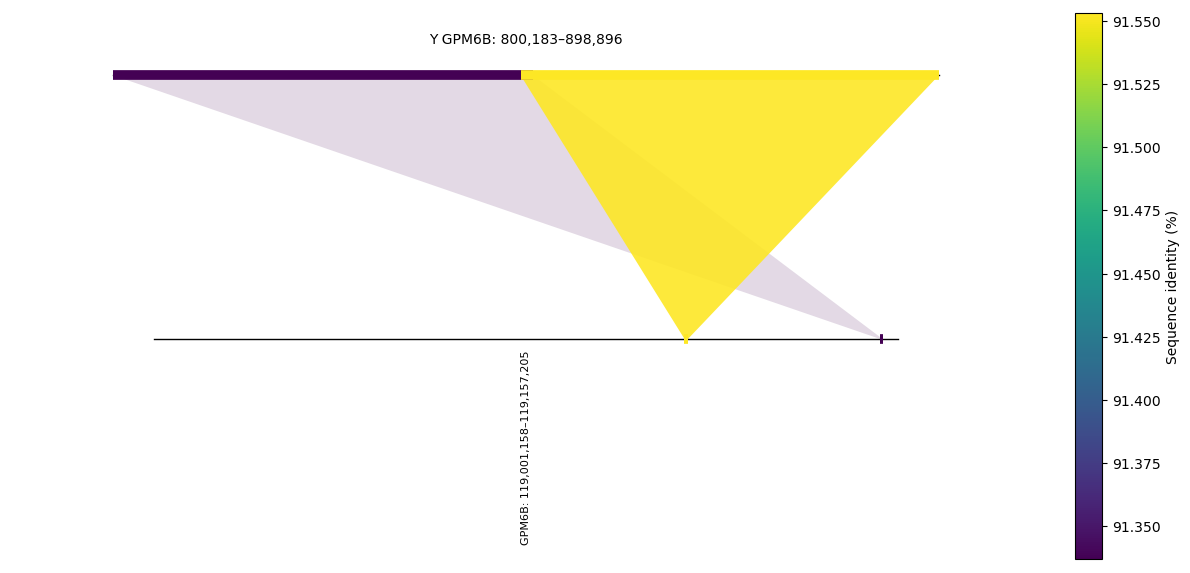

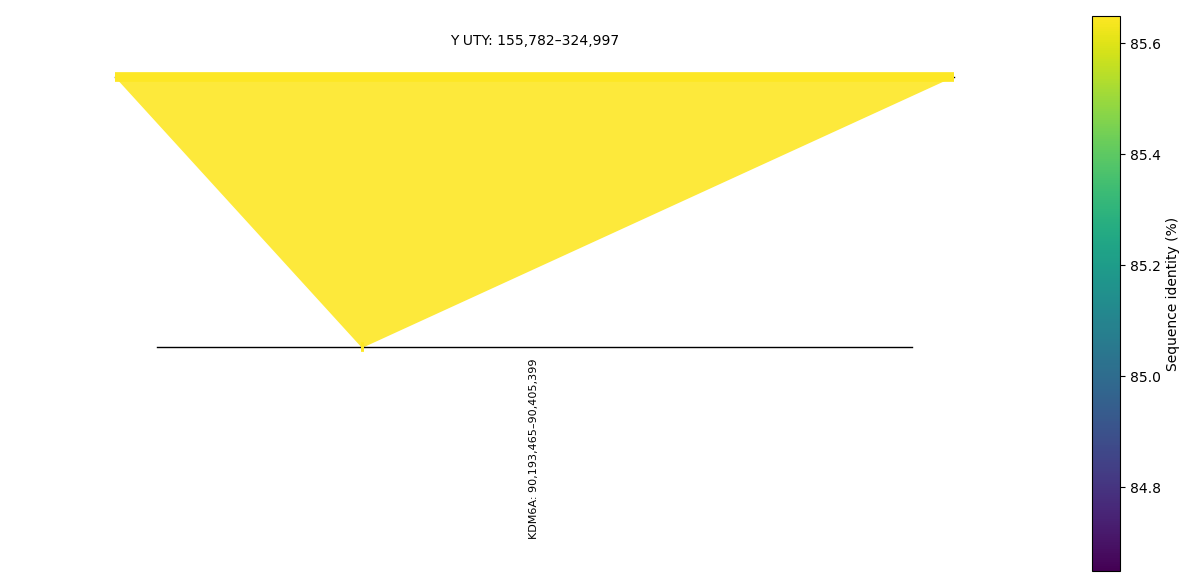

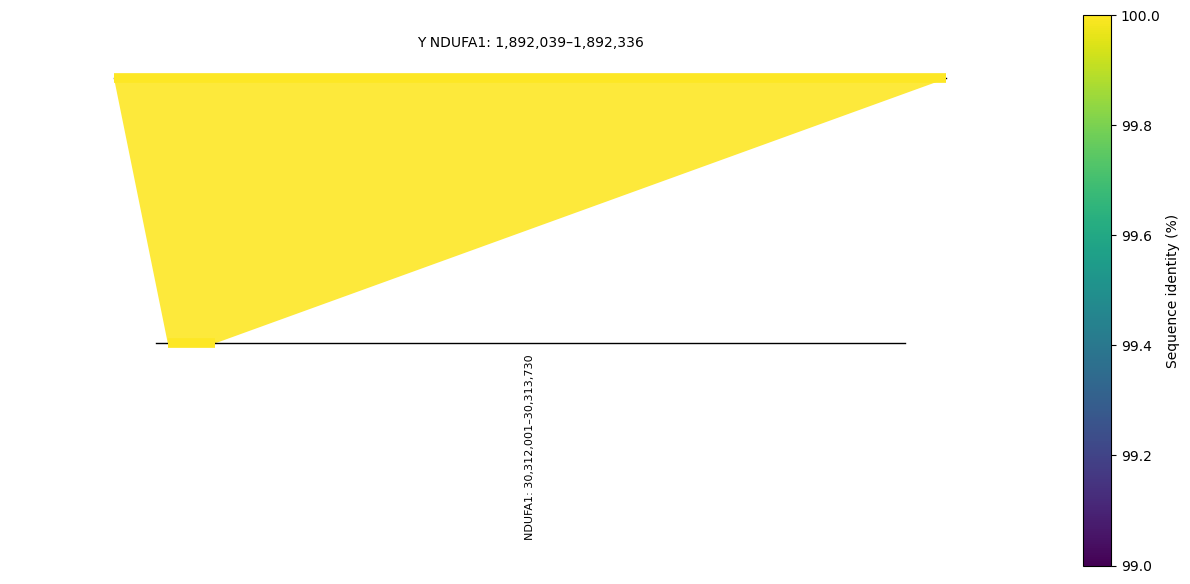

In [12]:
# IDT50.W100
get_identity_plots(ident=50, len=100)

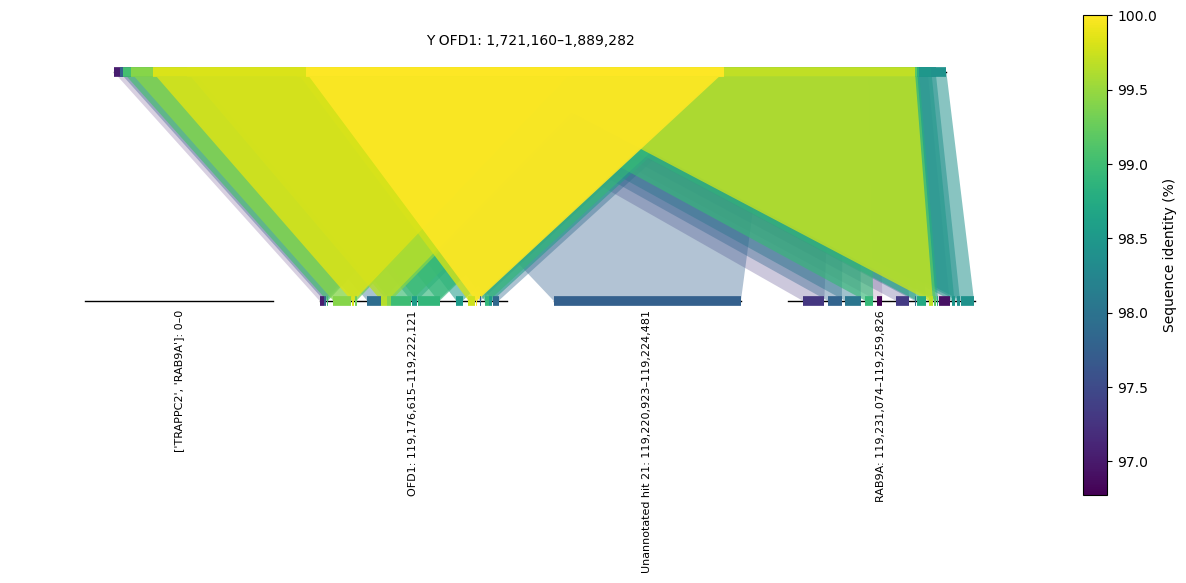

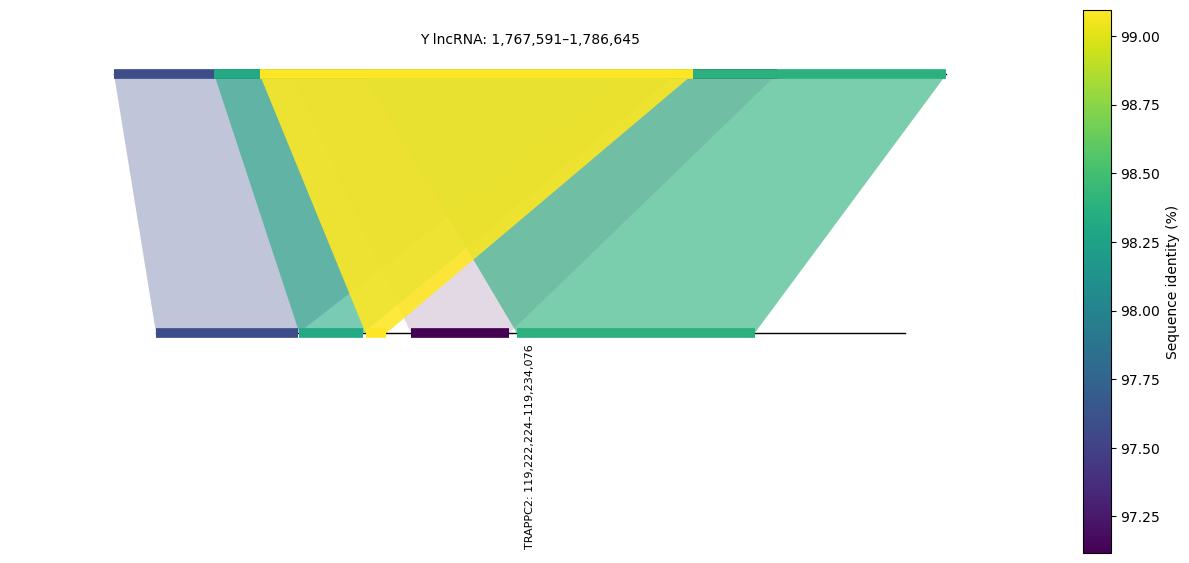

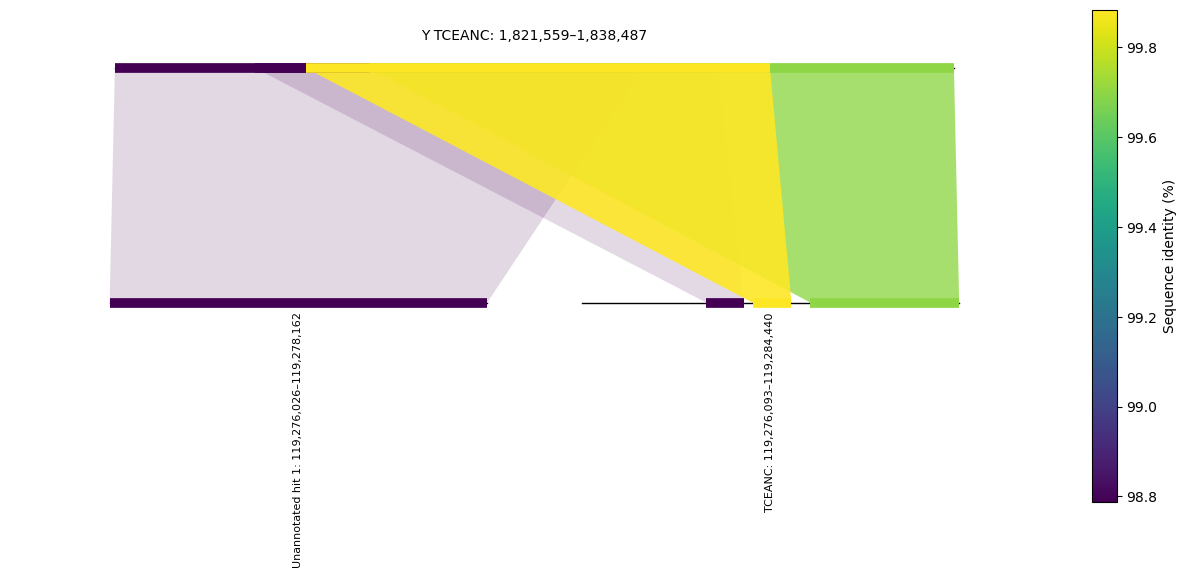

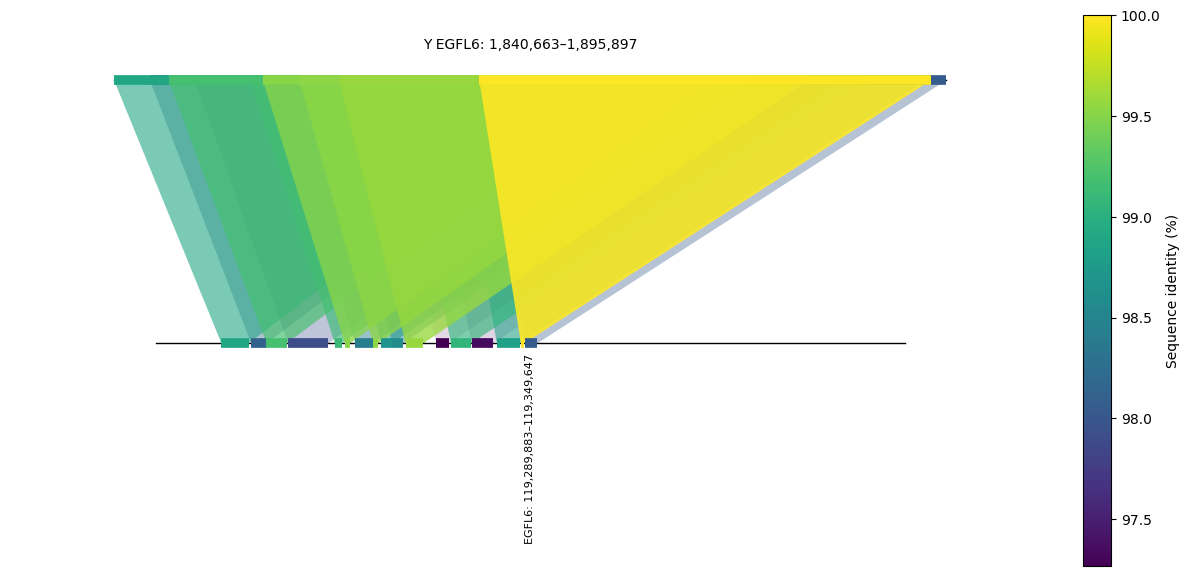

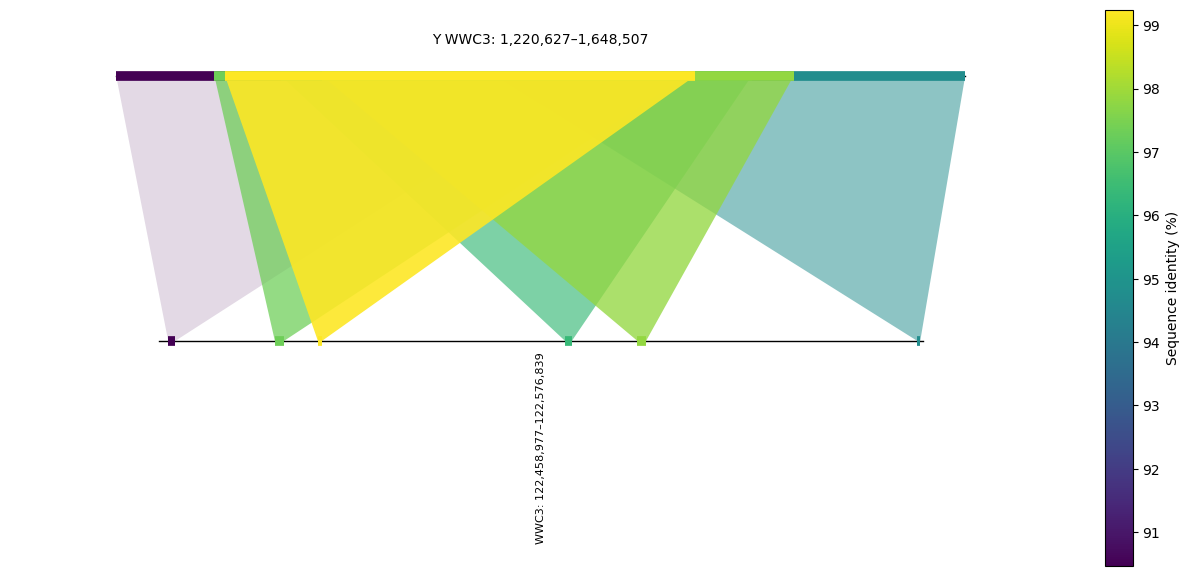

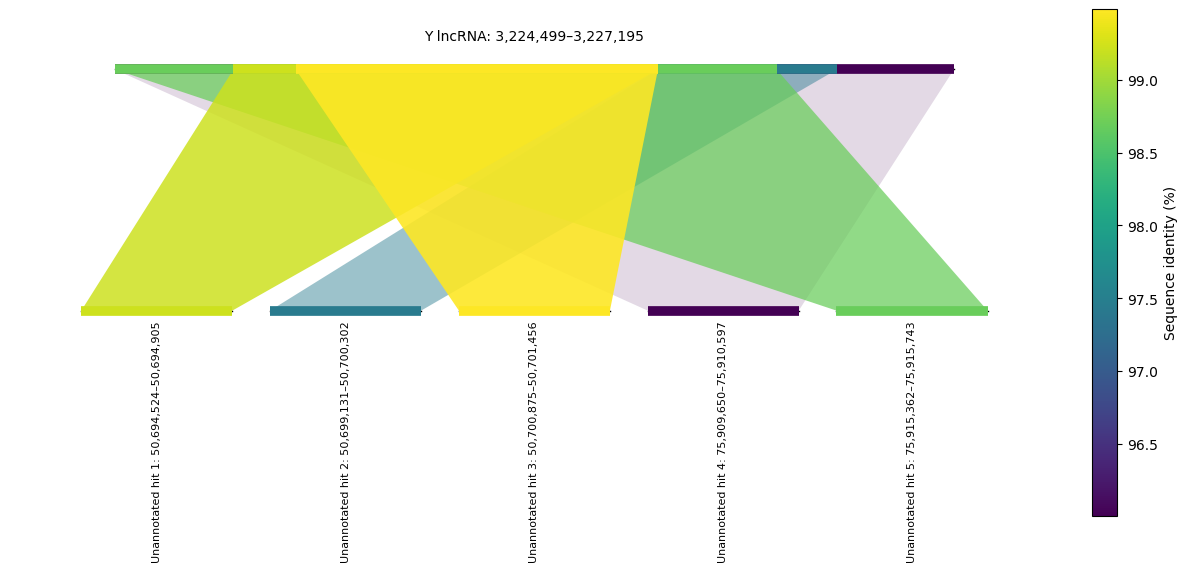

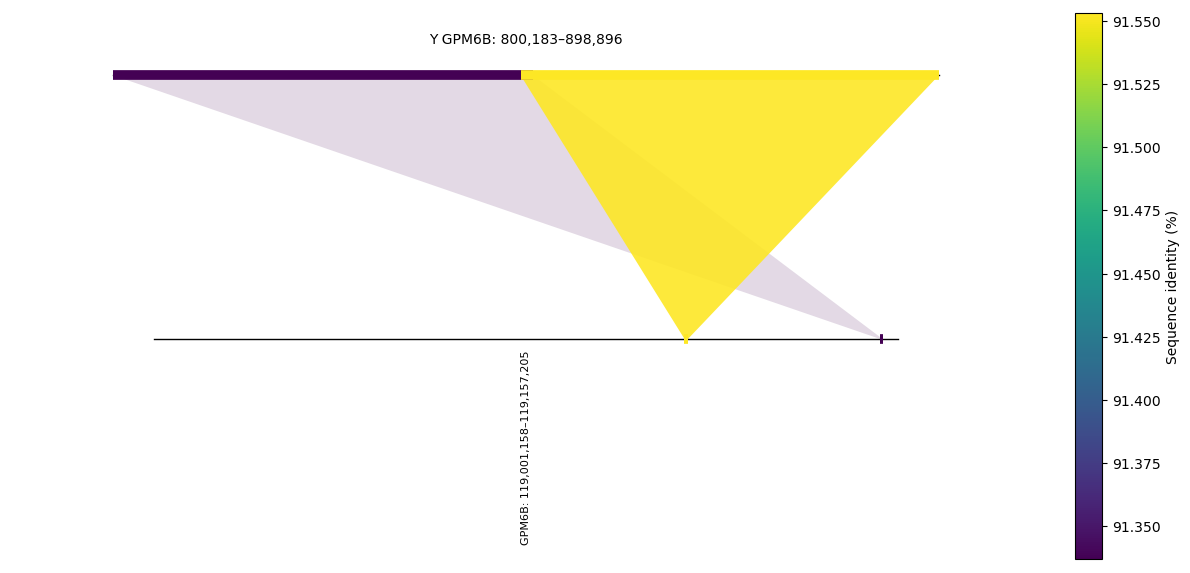

In [13]:
# IDT50.W125
get_identity_plots(ident=50, len=125)

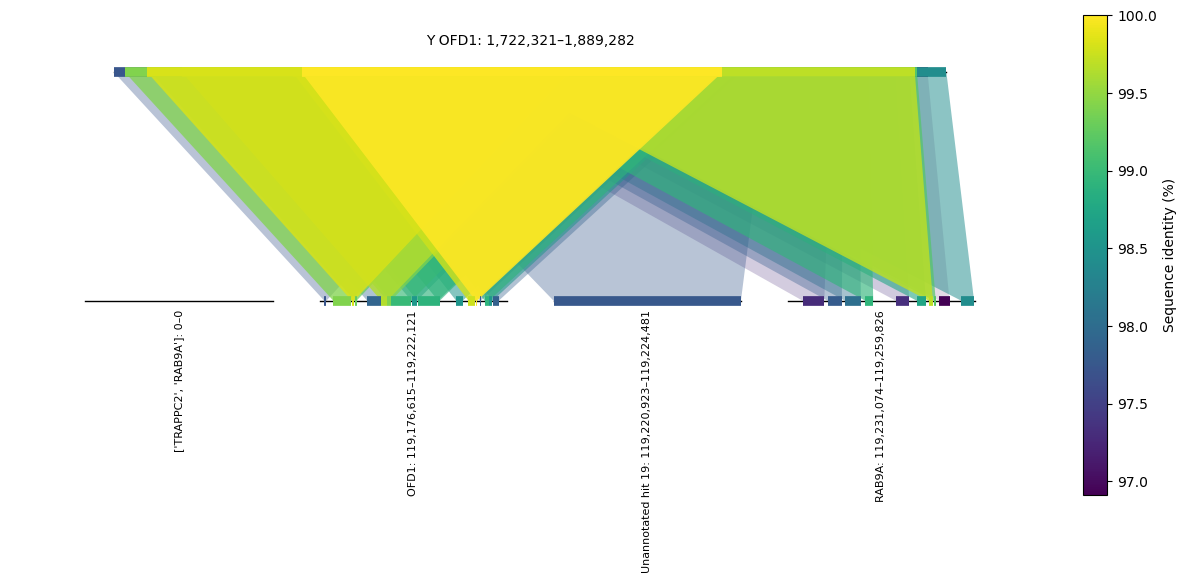

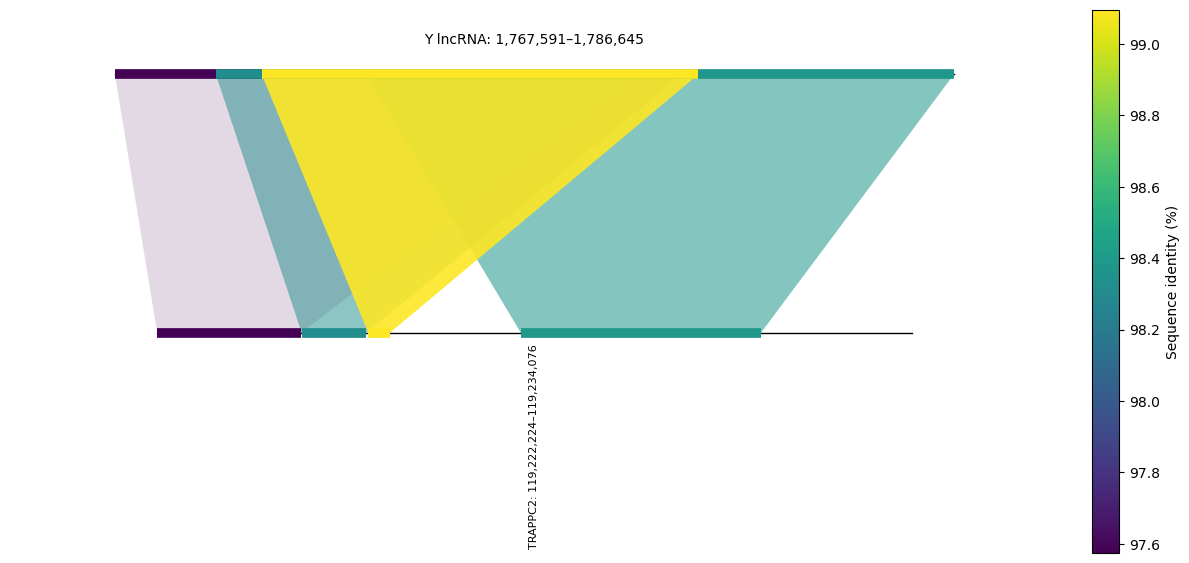

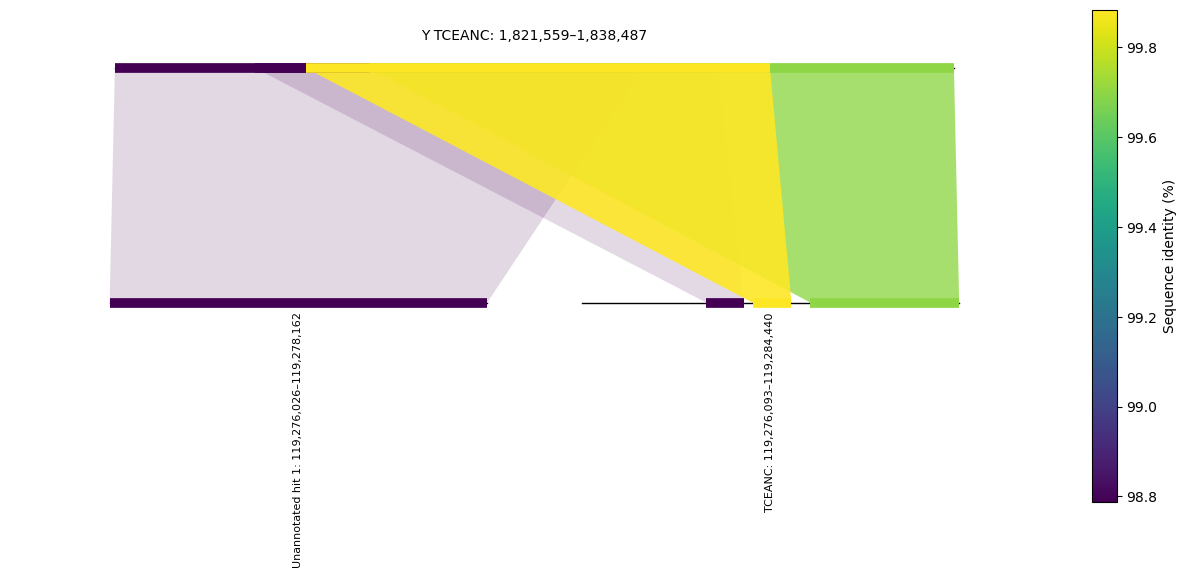

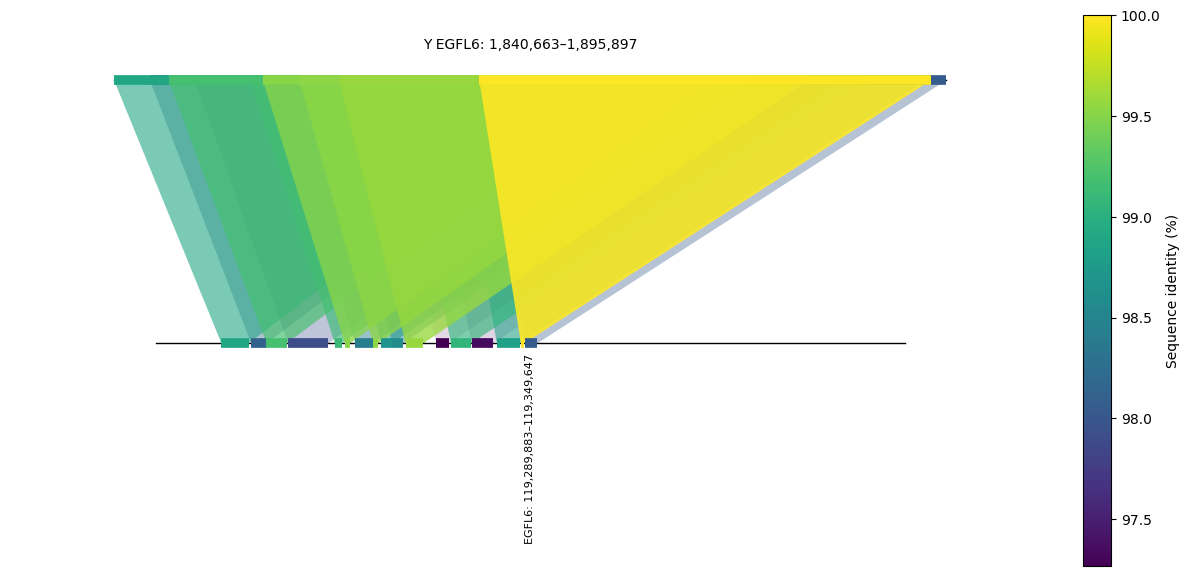

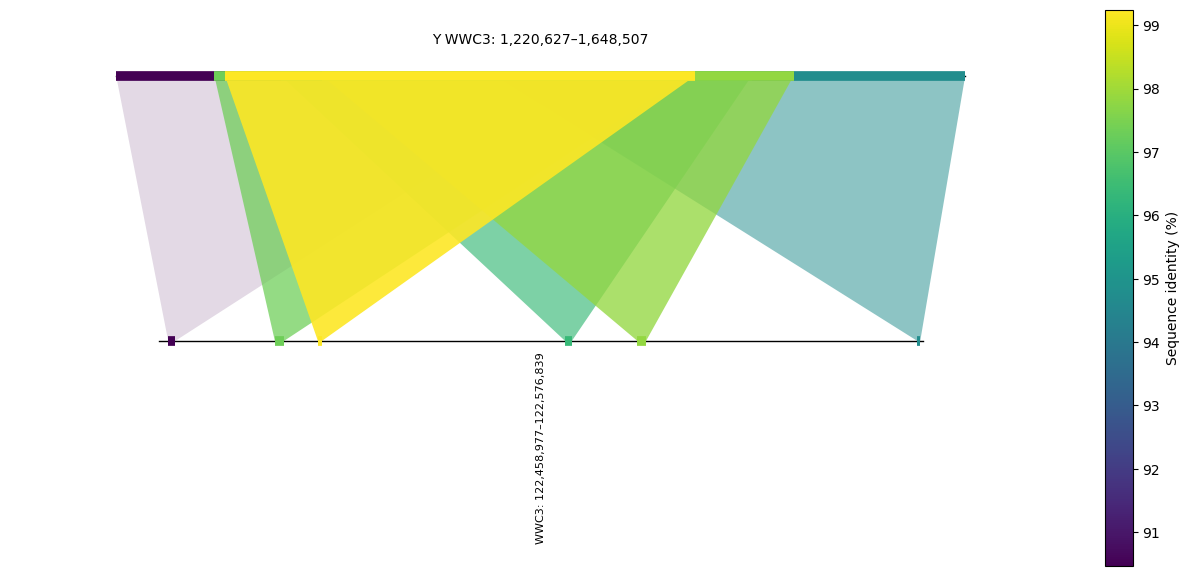

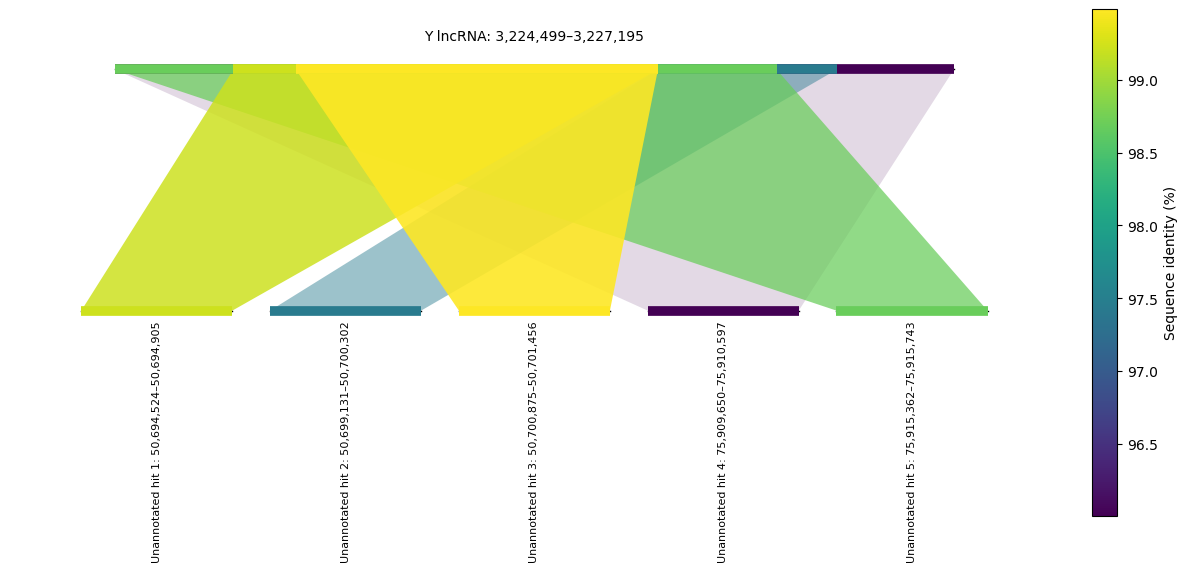

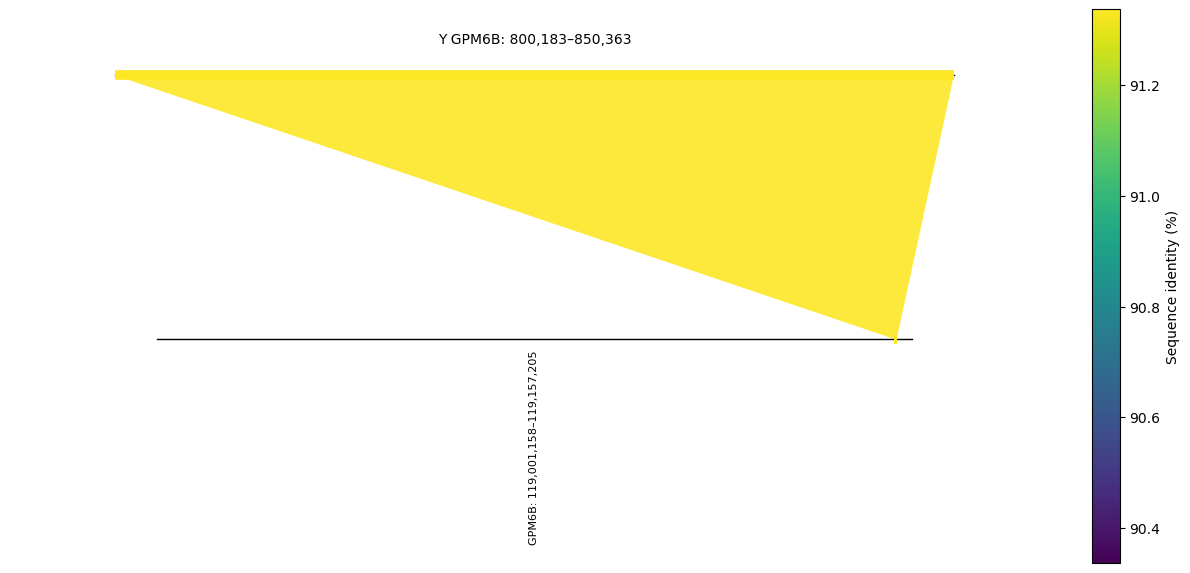

In [14]:
# IDT50.W150
get_identity_plots(ident=50, len=150)